<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.en/cap07/cap07_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

# 7 Image Classification and Pattern Recognition

In **Chapter 6**, the transition from Part I to Part II was presented through two applications that already required automated decisions: mark recognition on answer sheets (OMR) and defect detection in industrial inspection. In both cases, however, the decisions relied on geometric rules and manually defined thresholds, such as determining whether a disk was sufficiently circular or whether a region was dark enough.

This chapter formalizes the more general problem underlying these applications: given a set of labeled examples, how can a system be trained to **automatically classify** new images or regions of interest? This question lies at the core of **Pattern Recognition**, a discipline that underpins much of modern Computer Vision tasks, from image classification to object detection and semantic segmentation, explored in the following chapters.

The main **classical image descriptors** (color, texture, and shape/gradient) and the **k-Nearest Neighbors** (*k-NN*) classifier will be studied, chosen for its conceptual simplicity and for directly highlighting the relationship between the feature space, distance metrics, and decision boundaries — concepts that remain central even in classifiers based on deep neural networks, studied in the final chapter of this part.

## 7.1 Chapter Objectives

By the end of this chapter, the student should be able to:

* **Understand the classical pattern recognition pipeline**: acquisition, preprocessing, descriptor extraction, classification, and evaluation;
* **Extract and interpret classical descriptors** of color, texture (*Local Binary Patterns* — LBP), and shape/gradient (*Histogram of Oriented Gradients* — HOG);
* **Implement and train a k-NN classifier** for image classification tasks;
* **Evaluate classifiers** using metrics such as accuracy, confusion matrix, precision, and recall;
* **Analyze the effect of the k parameter** and the dimensionality of the feature space on classifier performance;
* **Recognize the limitations of hand-crafted features** and understand the motivation for the transition, in the following chapters, to automatically learned descriptors.

## 7.2 Environment Setup

The examples in this chapter use libraries that are widely employed in
Digital Image Processing, Computer Vision, and Machine Learning. The block
below installs the necessary packages; in environments where they are
already available, the execution can be skipped.

In [1]:
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup()
from morph import mm

import importlib
import subprocess
import sys

def setup_cap07():
    """Installs missing libraries needed for this chapter
    (computer vision and machine learning)."""
    pacotes = {
        "cv2": "opencv-python",
        "skimage": "scikit-image",
        "numpy": "numpy",
        "sklearn": "scikit-learn",
        "matplotlib": "matplotlib",
        "pandas": "pandas",
        "seaborn": "seaborn",
        "tabulate": "tabulate",
        "kaleido": "kaleido",
    }
    for modulo, pacote in pacotes.items():
        if importlib.util.find_spec(modulo) is None:
            resultado = subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", pacote]
            )
            if resultado.returncode != 0:
                print(f"[WARNING] Failed to install {pacote} (needed for the module {modulo}).")


setup_cap07()

# ==========================================================
# Libraries
# ==========================================================

# Scientific computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

# Computer vision
import cv2
from skimage import data as skdata
from skimage.feature import hog, local_binary_pattern

# Machine learning
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

✅ Environment ready. Morph: 1.1.9 | OpenCV: 5.0.0


## 7.3 A Concrete Problem: Fruit Classification

Before presenting the theoretical foundations, consider the following problem,
which will be used as an example throughout this chapter to illustrate the
main concepts of pattern recognition.

**The scenario:** An automated farm uses a Computer Vision
system to separate apples, bananas, and oranges on packaging
lines.

**The challenge:** The fruits arrive on the conveyor belt in different positions and
orientations, under lighting conditions that may vary. Furthermore,
leaves, shadows, and small occlusions can hinder their identification.
How can we develop a system capable of classifying them correctly?

**A possible approach:**

1. Extract descriptors that represent relevant characteristics of the
   fruits:
   - **Color:** predominant color distribution;
   - **Texture:** differences in the peel surface;
   - **Shape:** geometric characteristics of the contour.

2. Train a classifier using previously labeled examples.

3. Use the trained model to automatically classify new
   fruits.

[Figure 7.1](#fig-07-frutas-motivacao) illustrates, conceptually, how different
fruits can be represented in a three-dimensional feature
space.

> ### 💡 Reflect before continuing
>
> If each fruit were represented only by the intensity values of
> its pixels, would it be possible to distinguish them reliably? What types of
> information could be extracted from the image to facilitate this task?

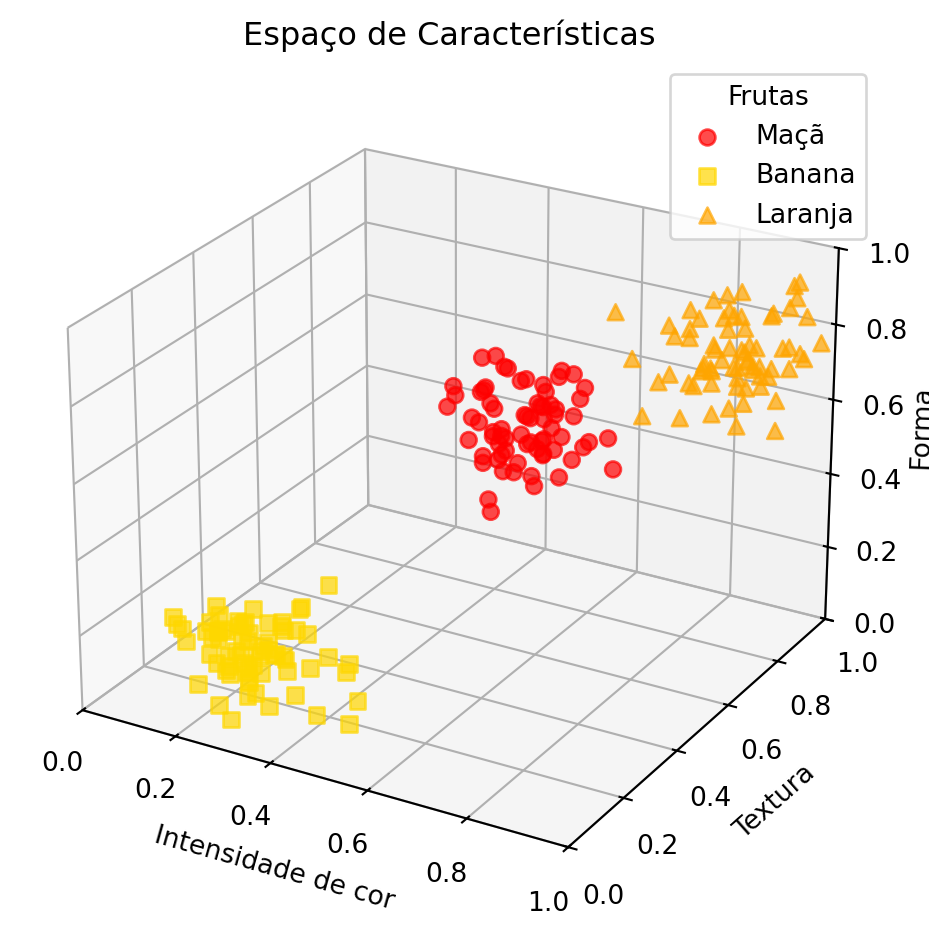

**Figure 7.1:** Motivational example: different fruits forming distinct clusters in a feature space.


In [2]:
np.random.seed(42)

centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")

for fruta, centro, cor, marcador in zip(
    centros,
    centros.values(),
    ["red", "gold", "orange"],
    ["o", "s", "^"],
):
    X = np.clip(np.random.normal(centro, 0.08, (70, 3)), 0, 1)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2],
               c=cor, marker=marcador, s=35,
               alpha=0.7, label=fruta)

ax.set(
    xlim=(0,1), ylim=(0,1), zlim=(0,1),
    xlabel="Intensidade de cor",
    ylabel="Textura",
    zlabel="Forma",
    title="Espaço de Características"
)
ax.view_init(elev=25, azim=-60)
ax.legend(title="Frutas")
ax.zaxis.labelpad = 0.01

plt.tight_layout()
plt.show()

## 7.4 🗺️ Chapter Overview: The Classic Image Classification *Pipeline*

Before proceeding, it is useful to present an integrated view of what
will be studied. [Figure 7.2](#fig-07-infografo) shows the general flow of a
classic image classification system, from the input image to the
final label assignment stage. In the following sections, each of the
stages of this process will be studied in detail.

<figure id="fig-07-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figure 7.2:</strong> Overview of the classic image classification *pipeline*: descriptor extraction (LBP, HOG), formation of the feature space, and classification via k-NN. Not applicable to Deep Learning models (CNNs, YOLO), which learn *features* end-to-end directly from pixels. **Source:** prepared with the aid of Gemini Notebook ({GOOGLE}, 2025).</figcaption>
</figure>

> ### 📝 Scope of this chapter
>
> In this chapter, the focus falls exclusively on the k-NN classifier,
> due to its didactic simplicity and its intuitive illustration of the
> concept of feature space. Other traditional classifiers widely used in
> Pattern Recognition — such as Decision Trees, Classification Rules, and
> Support Vector Machines (SVM) — are discussed in depth in
> Quilici-gonzalez (2014), especially in its 2nd edition, currently
> in production (QUILICI-GONZALEZ, 2026).

## 7.5 Fundamentals of Pattern Recognition

A **pattern recognition** system aims to assign a category (label) to an observation — an entire image, a region of interest, or a signal — based on previously labeled examples. In general, this process is organized into the following steps:

1. **Acquisition:** obtaining the image or signal to be classified;
2. **Pre-processing:** normalization, noise removal, geometric or illumination correction — steps already studied in previous chapters;
3. **Feature extraction:** transformation of the image into a **feature vector** of fixed dimension, which represents the relevant properties for the classification task;
4. **Classification:** application of a model that associates the feature vector with a class;
5. **Evaluation:** analysis of the model's performance on a dataset independent of the one used for training.

The set of all possible feature vectors constitutes the **feature space**. A good descriptor produces representations that, in this space, bring observations of the same class closer together and separate observations of distinct classes. This property favors classification methods based on proximity, such as **k-NN**, and also benefits several other classifiers.

[Figure 7.1](#fig-07-frutas-motivacao) illustrates this concept schematically: each fruit is represented by a point in a three-dimensional feature space (color, texture, and shape). Although this space is merely a didactic simplification, it shows how samples from the same class tend to form clusters, while different classes occupy distinct regions, facilitating the classification task.

## 7.6 Extraction of Classical Descriptors

Before the popularization of deep neural networks, image descriptors
were mostly hand-crafted by specialists, based on known statistical
or geometric properties. Three classical families are particularly
relevant:

* **Color descriptors:** intensity or hue histograms, which capture
  the distribution of color values in a region, already introduced
  in **Chapter 3** through the `mm.hist` function;
* **Texture descriptors:** capture local patterns of repetition,
  roughness, or orientation, such as *Local Binary Patterns* (LBP),
  studied below;
* **Shape/gradient descriptors:** describe the distribution of edges
  and gradient orientations, such as the *Histogram of Oriented
  Gradients* (HOG), widely used in the detection of people and other
  objects.

To compare the information captured by each approach, [Figure 7.3](#fig-07-visualizacao-descritores)
shows how different techniques "see" the same image.

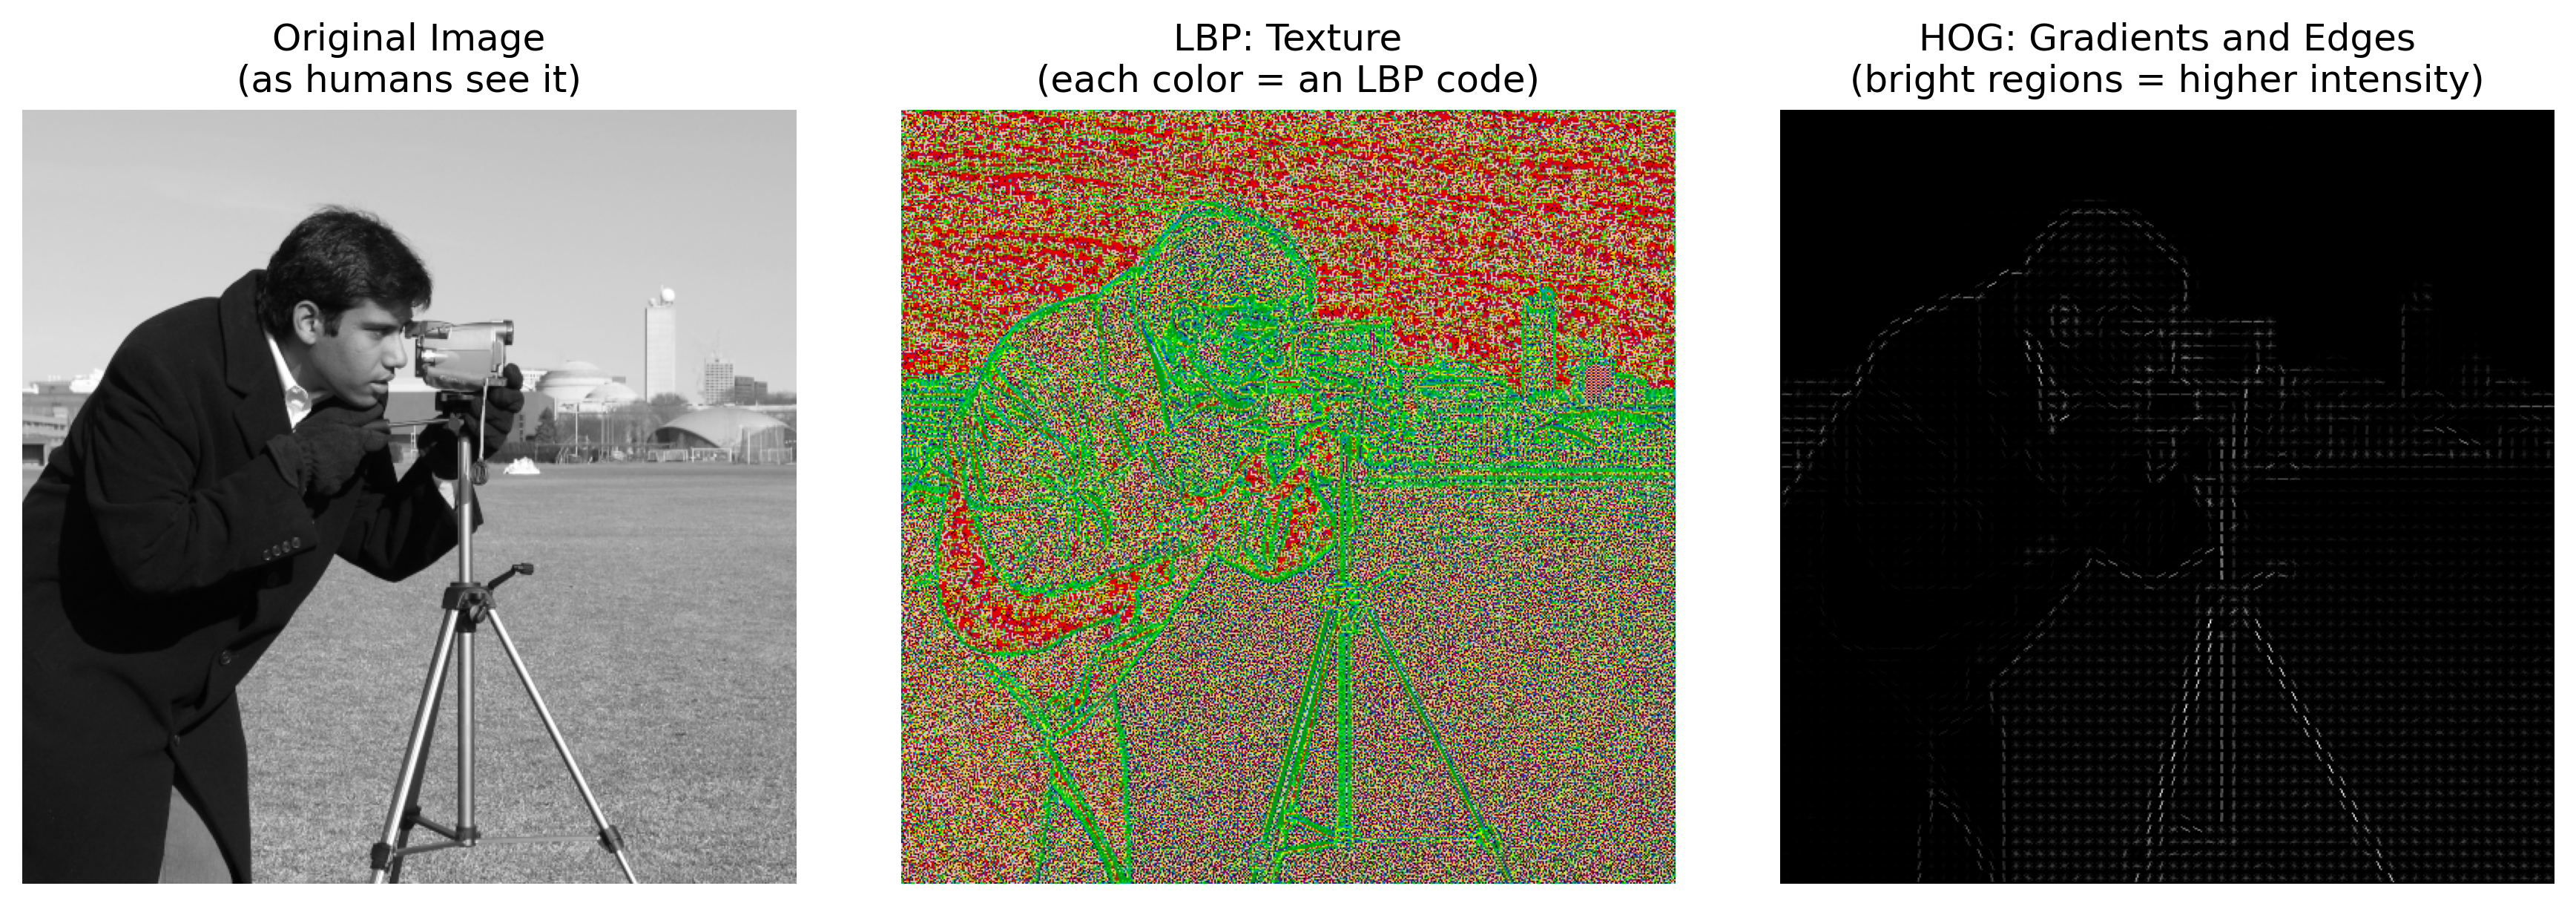

**Figure 7.3:** Visual comparison of different descriptors applied to the same image. Each descriptor reveals distinct aspects of the scene.


Notice how each descriptor highlights different properties:
• LBP: highlights local texture patterns.
• HOG: highlights edges and border orientations.
• Original image: contains only intensity values.


In [3]:
# Load example image
imagem = skdata.camera()

# Apply descriptors
lbp_img = local_binary_pattern(
    imagem, 
    P=8, 
    R=1, 
    method="uniform"
    )

# Convert LBP to RGB only to facilitate visualization
lbp_norm = (lbp_img - lbp_img.min()) / (lbp_img.max() - lbp_img.min() + 1e-8)
lbp_rgb = (cm.nipy_spectral(lbp_norm)[..., :3] * 255).astype("uint8")

hog_features, hog_img = hog(
    imagem,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
)

# Standardized display
mm.show(
    [imagem, lbp_rgb, hog_img],
    titles=[
        "Original Image\n(as humans see it)",
        "LBP: Texture\n(each color = an LBP code)",
        "HOG: Gradients and Edges\n(bright regions = higher intensity)",
    ],
    cols=3,
    figsize=(12, 4),
)

print("Notice how each descriptor highlights different properties:")
print("• LBP: highlights local texture patterns.")
print("• HOG: highlights edges and border orientations.")
print("• Original image: contains only intensity values.")

### 7.6.1 *Local Binary Patterns* (LBP)

LBP is a texture descriptor that encodes, for each central pixel
$g_c$, the relationship between its intensity and that of the $P$ neighbors arranged in
a circular neighborhood of radius $R$:

$$
\mathrm{LBP}_{P,R}(x_c, y_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\, 2^p,
\qquad
s(z) =
\begin{cases}
1, & z \geq 0 \\
0, & z < 0
\end{cases}
$$

where:

- $(x_c, y_c)$ are the coordinates of the central pixel;
- $g_c$ is the intensity of the central pixel;
- $g_p$ is the intensity of the $p$-th neighboring pixel;
- $P$ is the number of neighbors considered;
- $R$ is the radius of the circular neighborhood;
- $p$ is the neighbor index, with $p = 0, 1, \ldots, P-1$;
- $s(z)$ is the threshold function defined in the equation, where $z = g_p - g_c$;
  it assumes a value of 1 when $z \geq 0$ and 0 when $z < 0$;
- $2^p$ corresponds to the binary weight associated with the $p$-th neighbor.

The resulting LBP code describes the local contrast pattern around the pixel. The histogram of these codes forms a compact feature vector for representing image texture ([Figure 7.4](#fig-07-vetor-lbp)). In this chapter, the **uniform** variant is used, which groups non-uniform patterns into a single category, reducing dimensionality and increasing the robustness of the descriptor.

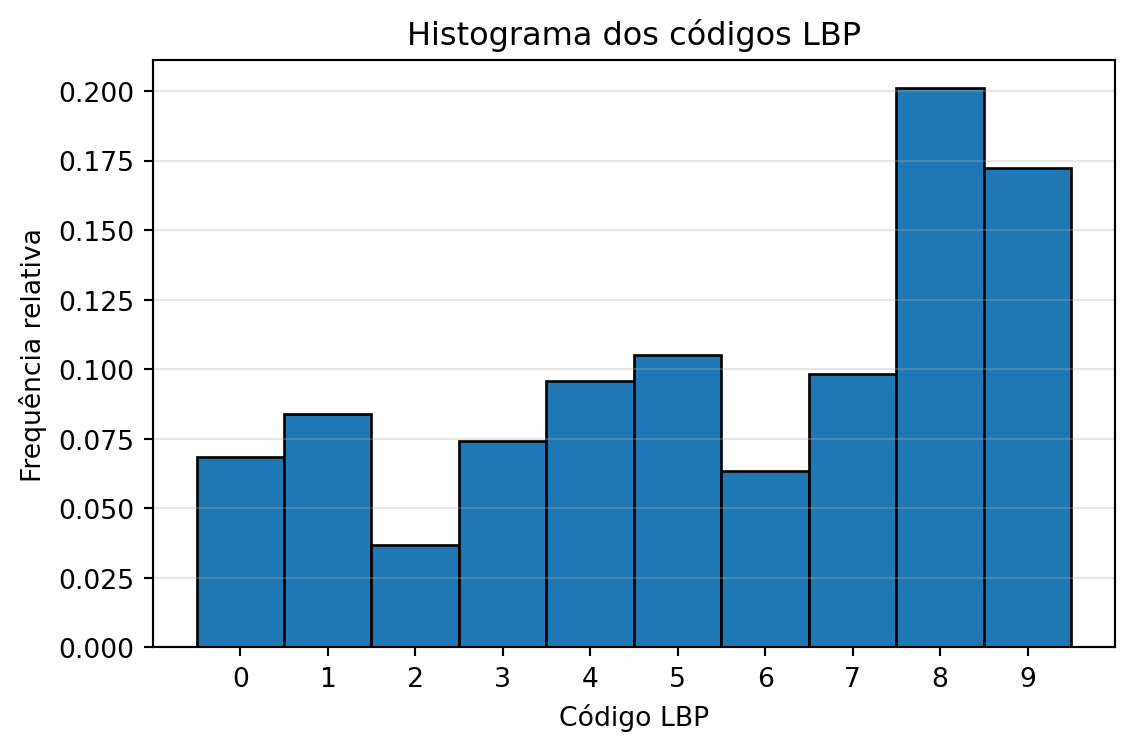

**Figure 7.4:** Histogram of LBP codes from the cameramen image. Each bar represents the relative frequency of an LBP code, forming the feature vector used to describe the texture.


In [4]:
plt.figure(figsize=(6, 4))

plt.hist(
    lbp_img.ravel(),
    bins=np.arange(-0.5, lbp_img.max() + 1.5, 1),
    density=True,
    edgecolor="black",
)

plt.title("Histograma dos códigos LBP")
plt.xlabel("Código LBP")
plt.ylabel("Frequência relativa")
plt.xticks(range(int(lbp_img.max()) + 1))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### 💡 Function `local_binary_pattern`
>
> The implementation used in this chapter is provided by the library
> `scikit-image`:
>
> ```python
> local_binary_pattern(
>     imagem,
>     P=8,
>     R=1,
>     method="uniform"
> )
> ```
>
> where:
>
> * `image`: grayscale image;
> * `P`: number of equally spaced neighbors in the circular neighborhood;
> * `R`: radius of the neighborhood, in pixels;
> * `method`: encoding strategy. In this chapter, the value `"uniform"` is used.
>
> The equation presented earlier describes the **original LBP**. In
> the implementation adopted in this chapter, the `method="uniform"`
> option initially calculates this code and then remaps non-uniform
> patterns into a single category, reducing the dimensionality of the
> descriptor and making it more robust to small local variations.

[Figure 7.3](#fig-07-visualizacao-descritores) presents the visual representation of the LBP, while [Figure 7.4](#fig-07-vetor-lbp) shows the histogram of LBP codes used as a feature vector.

**Practical Project 2** (section **Comparison of Descriptors for Texture Classification**) employs LBP in the classification of different types of synthetic texture.

### 7.6.2 *Histogram of Oriented Gradients* (HOG)

HOG is a descriptor that represents the shape of an object through the
distribution of local gradient orientations. As in the Canny operator
(**Chapter 6**), the gradient is initially computed:

$$
|\nabla f(x,y)| =
\sqrt{\left(\frac{\partial f}{\partial x}\right)^2 +
      \left(\frac{\partial f}{\partial y}\right)^2},
\qquad
\theta(x,y) =
\operatorname{atan2}\!\left(
\frac{\partial f}{\partial y},
\frac{\partial f}{\partial x}
\right).
$$

where:

- $f(x,y)$ is the image intensity at pixel $(x,y)$;
- $\frac{\partial f}{\partial x}$ and $\frac{\partial f}{\partial y}$ are,
  respectively, the partial derivatives of the image in the horizontal
  and vertical directions;
- $|\nabla f(x,y)|$ is the magnitude of the gradient vector at pixel $(x,y)$,
  indicating the strength of the local variation in the image;
- $\theta(x,y)$ is the orientation of the gradient vector at pixel $(x,y)$,
  computed by the function $\operatorname{atan2}$, whose result belongs to the
  interval $(-\pi,\pi]$.

Although $\theta(x,y)$, as computed by the function $\operatorname{atan2}$, belongs to the interval $(-\pi,\pi]$, the standard HOG implementation uses the **unsigned gradient**: opposite orientations (e.g., $0$ and $\pi$) are treated as equivalent, and the angles are mapped to the interval $[0,\pi)$ before constructing the histogram. This choice makes the descriptor invariant to the direction of contrast (e.g., a light-dark edge and a dark-light edge produce the same orientation).

The image is then divided into **cells**. For each cell,
a histogram of gradient orientations is constructed, weighted by the
corresponding magnitude. The concatenation of the histograms from all
cells forms the HOG feature vector, which represents the
spatial distribution of gradient orientations and captures information
about the shape and contours of the object ([Figure 7.5](#fig-07-vetor-hog)).

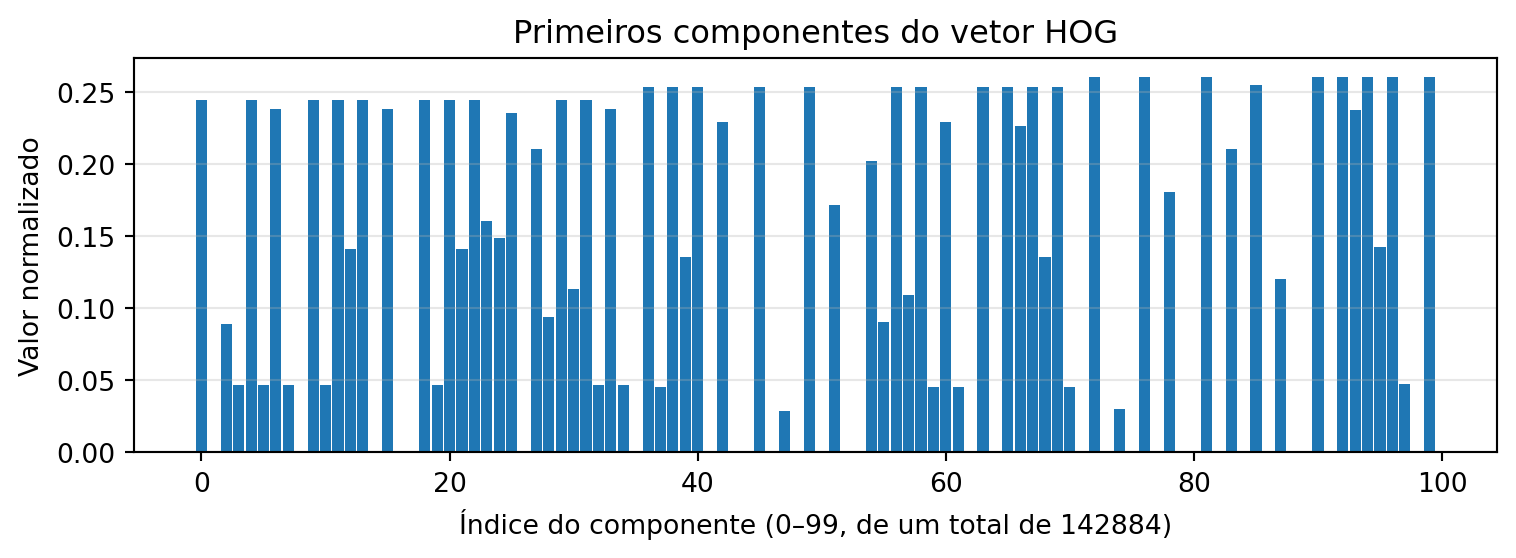

**Figure 7.5:** First 100 components of the HOG feature vector.


In [5]:
n = 100

plt.figure(figsize=(8, 3))
plt.bar(
    range(n),
    hog_features[:n],
    width=0.9
)

plt.title("Primeiros componentes do vetor HOG")
plt.xlabel(f"Índice do componente (0–{n-1}, de um total de {hog_features.shape[0]})")
plt.ylabel("Valor normalizado")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

> ### 💡 Function `hog`
>
> The extraction of the HOG descriptor is performed by the function:
>
> ```python
> hog(
>     image,
>     orientations=9,
>     pixels_per_cell=(8, 8),
>     cells_per_block=(2, 2),
>     visualize=True,
> )
> ```
>
> The main parameters are:
>
> * `image`: input image;
> * `orientations`: number of angular divisions of the orientation histogram in each cell;
> * `pixels_per_cell`: size, in pixels, of each cell where the histogram is computed;
> * `cells_per_block`: number of cells used in descriptor normalization;
> * `visualize`: when `True`, it also returns an image illustrating the gradients used by the HOG.
>
> The equation presented previously describes the computation of the gradient magnitude and orientation, which form the basis of the HOG descriptor. In the implementation adopted in this chapter, the `hog()` function uses this information to build orientation histograms in each cell of the image and then performs block normalization (`cells_per_block`), reducing the descriptor's sensitivity to variations in illumination and contrast.


[Figure 7.3](#fig-07-visualizacao-descritores) presents the visual representation of the HOG, while [Figure 7.5](#fig-07-vetor-hog) illustrates the first components of the feature vector extracted from the image.

**Practical Project 1** (section **Classification of Handwritten Digits with k-NN**) compares the performance of HOG descriptors with the direct use of pixel intensities as the feature vector.

### 7.6.3 The Impact of Scale and Feature Normalization

The $k$-NN classifier makes its decisions based on the distance between
feature vectors. Therefore, the scale of each feature
directly influences the classification outcome. If a variable
has values much larger than the others (for example, a
color intensity ranging from $0$ to $255$, while a
circularity index ranges from $0$ to $1$), it tends to dominate the distance
calculation, reducing the influence of the other descriptors.

To avoid this issue, a **feature normalization**
step is applied, typically through standardization (*Z-score
standardization*). In this procedure, each feature is adjusted to have
a mean of zero and a standard deviation of one, making
quantities originally measured on different scales comparable.

Standardization is performed through the transformation

$$
z = \frac{x - \mu}{\sigma},
$$

where:

- $x$ is the original value of the feature;
- $\mu$ is the mean of that feature computed over the training set;
- $\sigma$ is the standard deviation of the feature;
- $z$ is the standardized value.

After this transformation, all features have a mean
equal to zero and a standard deviation equal to one, allowing them to contribute
in a balanced manner to the distance calculation.

> ### 💡 `StandardScaler` Class
>
> The standardization used in this chapter is performed by the
> `StandardScaler` class from the `scikit-learn` library:
>
> ```python
> from sklearn.preprocessing import StandardScaler
>
> scaler = StandardScaler()
> X_norm = scaler.fit_transform(X)
> ```
>
> where:
>
> * `StandardScaler()`: creates the object responsible for standardization;
> * `fit_transform(X)`: computes the mean and standard deviation of each
>   feature in the set `X` and returns the standardized matrix.
>
> In practice, the `fit_transform()` method performs two steps: first
> (`fit`), it estimates the mean ($\mu$) and the standard deviation ($\sigma$) of each
> feature; then (`transform`), it applies the standardization transformation presented earlier to all values in the input matrix.

[Figure 7.6](#fig-07-normalizacao-features) shows the effect of normalization.
Visually, the distribution of the points remains the same; what changes is the
scale of the axes. Without normalization, the feature with the greatest
magnitude dominates the distance calculation between samples. After standardization, all features contribute in a
balanced manner to the distance calculation used by the
$k$-NN classifier.

Effect of normalization:
  Feature 1: scale ≈ 100
  Feature 2: scale ≈ 1

Without normalization, the first feature dominates the distance calculation.
With normalization, both contribute in a balanced way.

Normalization is essential when features have different scales.


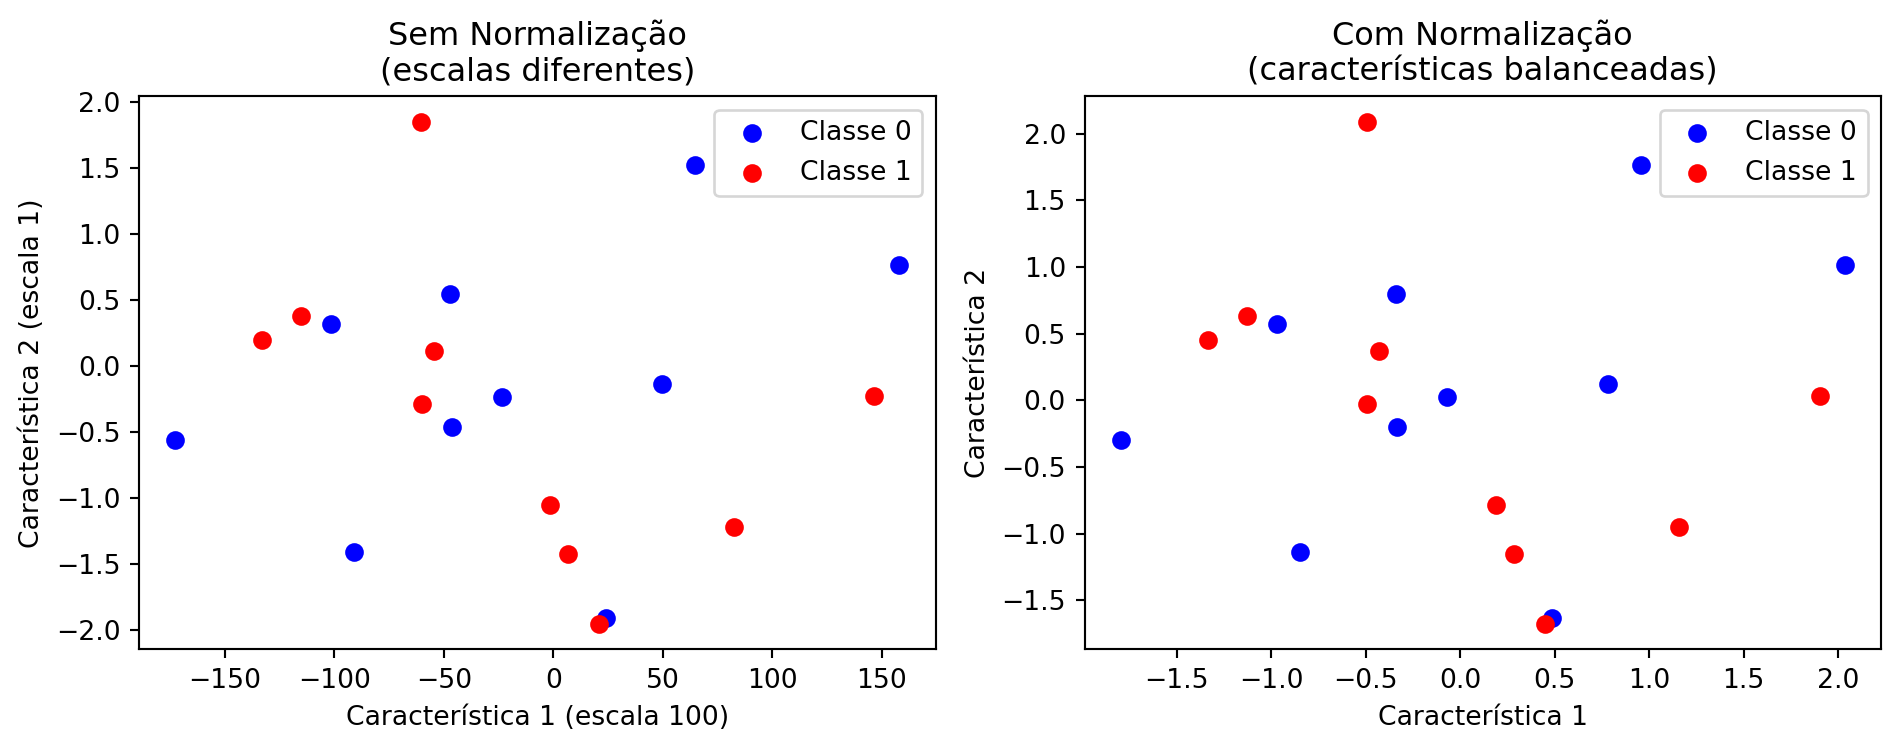

**Figure 7.6:** Importance of feature normalization for the k-NN classifier.


In [6]:
# Synthetic data with very different scales
np.random.seed(42)
X_demo = np.random.randn(20, 2) * [100, 1]
y_demo = np.array([0] * 10 + [1] * 10)

print("Effect of normalization:")
print("  Feature 1: scale ≈ 100")
print("  Feature 2: scale ≈ 1")
print("\nWithout normalization, the first feature dominates the distance calculation.")
print("With normalization, both contribute in a balanced way.")
print("\nNormalization is essential when features have different scales.")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Without normalization
axes[0].scatter(
    X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[0].scatter(
    X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[0].set_title("Sem Normalização\n(escalas diferentes)")
axes[0].set_xlabel("Característica 1 (escala 100)")
axes[0].set_ylabel("Característica 2 (escala 1)")
axes[0].legend()

# With normalization
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_demo)

axes[1].scatter(
    X_norm[y_demo == 0, 0], X_norm[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[1].scatter(
    X_norm[y_demo == 1, 0], X_norm[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[1].set_title("Com Normalização\n(características balanceadas)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.7 📌 Concept Map

Up to this point, we have presented the classical descriptors (LBP, HOG, raw pixels) and how they organize samples in a feature space. [Figure 7.7](#fig-07-mapa-conceitual) synthesizes this path and situates these steps within the overall flow of a classical image classification system, also indicating the subsequent steps — classification (k-NN) and result evaluation — which will be formalized in the following sections.

<figure id="fig-07-mapa-conceitual" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-mapa-conceitual.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figure 7.7:</strong> Concept map of the image classification process using classical descriptors (LBP, HOG, raw pixels) and a traditional classifier (k-NN). It does not apply to Deep Learning models (CNNs, YOLO), which learn *features end-to-end* directly from pixels.</figcaption>
</figure>

## 7.8 Descriptors in Practice

After learning about the main classical descriptors, it is natural to ask
how they influence the performance of a classifier in situations
close to those encountered in practice.

In this section, we compare the use of three distinct representations of the
same images: pixel intensities, LBP descriptors, and HOG
descriptors. To make the experiment more realistic, synthetic noise is added
to the data, at different intensities for each descriptor — a simplified
way of simulating the fact that, in practice, different
representations tolerate capture imperfections unequally
(sensor noise, small position variations, etc.).

[Figure 7.8](#fig-07-matrizes-confusao) presents the confusion matrices obtained
for each descriptor, allowing us to identify in which classes the main
classification errors occur.
The interpretation of these matrices was introduced in **Chapter 1**, when
the concepts of **True Positive (TP)**,
**False Positive (FP)**, **True Negative (TN)**, and **False Negative (FN)** were presented.
These concepts were explored in **EPs 01_02** (classification metrics)
and **01_03** (*mean Average Precision* – mAP), available at:

- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_02.html>
- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_03.html>

In this chapter, confusion matrices are used to analyze
how different descriptors influence classifier performance.

Next, [Figure 7.9](#fig-07-comparacao-descritores-detalhada) summarizes the overall
accuracy obtained by each descriptor.

The results show that classifier performance depends
directly on the representation chosen to describe the images.
While the direct use of pixel intensities is more sensitive to
the introduced degradations, LBP and HOG descriptors better preserve the
information relevant to classification, resulting in higher
performance in this scenario. It is important to emphasize that the noise levels
applied to each descriptor were chosen for didactic purposes only,
so as to illustrate the general principle that more elaborate descriptors
*may* be more robust to degradations — which does not mean that this
relationship always holds, as the case study in the next section
will demonstrate.

> ### 💡 How the experiment is conducted
>
> Since the goal of this section is to compare only the effect of the descriptors,
> a simple synthetic dataset is generated: three Gaussian point clouds,
> centered at the same "color, texture, and shape" values already
> used in [Figure 7.1](#fig-07-frutas-motivacao) — the same pattern employed since the
> beginning of the chapter to represent the three fruit classes.
>
> ```python
> import numpy as np
> from sklearn.model_selection import train_test_split
> from sklearn.neighbors import KNeighborsClassifier
> from sklearn.metrics import accuracy_score, confusion_matrix
> ```
>
> ```python
> centros = {
>     "Maçã":    [0.8, 0.2, 0.9],
>     "Banana":  [0.3, 0.1, 0.2],
>     "Laranja": [0.9, 0.8, 0.8],
> }
>
> n_por_classe = 100
> X = np.vstack([
>     np.random.normal(centro, 0.12, (n_por_classe, 3))
>     for centro in centros.values()
> ])
> y = np.repeat(list(centros.keys()), n_por_classe)
> ```
>
> where:
>
> * `centros`: dictionary with the mean point of each class in the feature space (color, texture, shape);
> * `n_por_classe`: number of samples generated per class;
> * `np.random.normal(centro, 0.12, (n_por_classe, 3))`: generates `n_por_classe` samples around each center, with a standard deviation of 0.12 in each dimension;
> * `np.repeat(list(centros.keys()), n_por_classe)`: generates the corresponding label vector, in the same order as the centers.
>
> Next, the training and evaluation pipeline is used:
>
> * `train_test_split(X, y, test_size=0.3)`: splits the data into training (70%) and testing (30%);
> * `KNeighborsClassifier(n_neighbors=5)`: creates a $k$-NN classifier with $k=5$ neighbors;
> * `fit(X_train, y_train)`: fits the model to the training data;
> * `predict(X_test)`: classifies the test samples;
> * `accuracy_score(y_test, y_pred)`: computes the accuracy;
> * `confusion_matrix(y_test, y_pred)`: generates the confusion matrix.
>
> In this experiment, the training set, the classifier, and the evaluation
> method remain exactly the same. The only difference between the
> experiments is the representation used for each image (raw pixels,
> LBP, or HOG), allowing the exclusive evaluation of the influence of the
> descriptor on the classifier's performance.

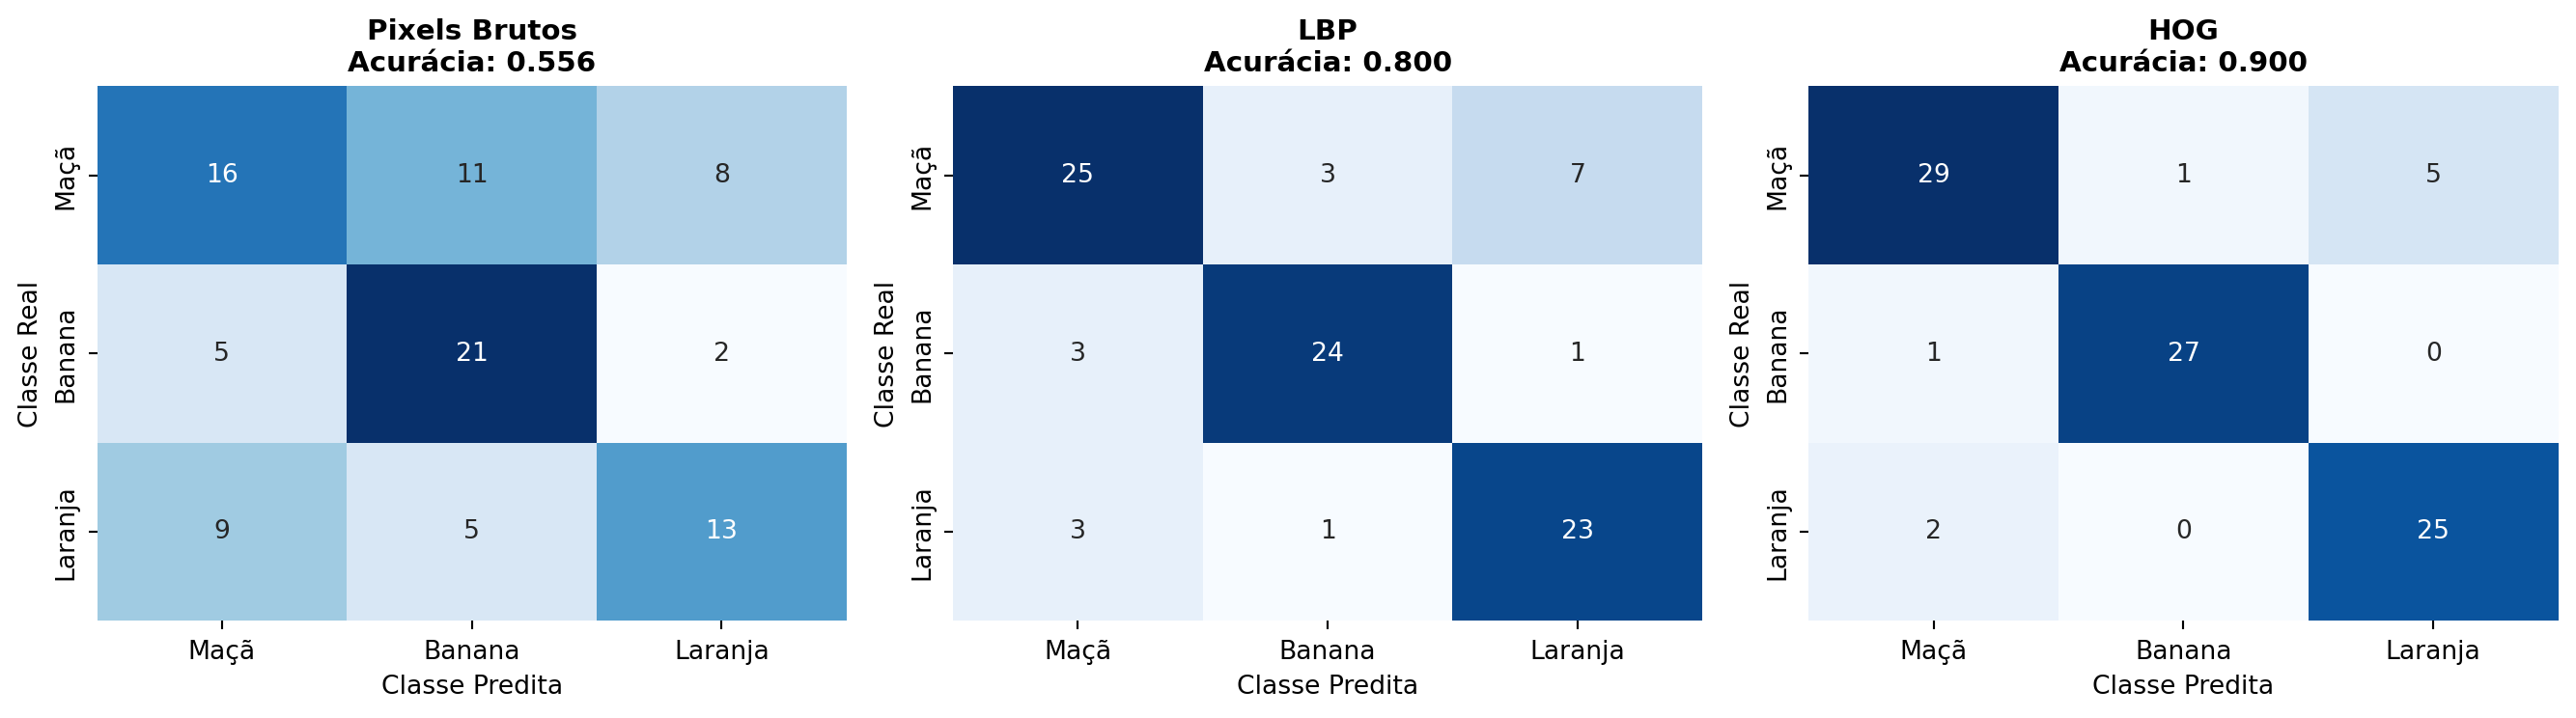

**Figure 7.8:** Confusion matrices obtained by the k-NN classifier using three different descriptors. The rows represent the actual class (Apple, Banana, and Orange) and the columns the predicted class. The greater the concentration of values on the main diagonal, the better the descriptor


In [7]:
classes = ["Maçã", "Banana", "Laranja"]

np.random.seed(42)

# Same class centers (color, texture, shape) used in the
# previous example, now reused to generate the synthetic
# training and testing data for this experiment.
centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

n_por_classe = 100
X = np.vstack([
    np.random.normal(centro, 0.12, (n_por_classe, 3))
    for centro in centros.values()
])
y = np.repeat(list(centros.keys()), n_por_classe)

# Simulate descriptors with different levels of sensitivity to noise.
# The more noise added, the worse the representation tends to be.
descritores = {
    "Pixels Brutos": X + 0.5 * np.random.randn(*X.shape),
    "LBP":           X + 0.3 * np.random.randn(*X.shape),
    "HOG":           X + 0.2 * np.random.randn(*X.shape),
}

# Create a single figure with 3 subplots side by side for the matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resultados = {}

for idx, (nome, Xd) in enumerate(descritores.items()):
    X_train, X_test, y_train, y_test = train_test_split(Xd, y, test_size=0.3, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    
    # Confusion matrix in the corresponding subplot

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[idx],
    )

    axes[idx].set_title(
        f"{nome}\nAcurácia: {acc:.3f}",
        fontsize=11,
        fontweight="bold"
    )
    axes[idx].set_xlabel("Classe Predita")
    axes[idx].set_ylabel("Classe Real")


plt.tight_layout()
plt.show()


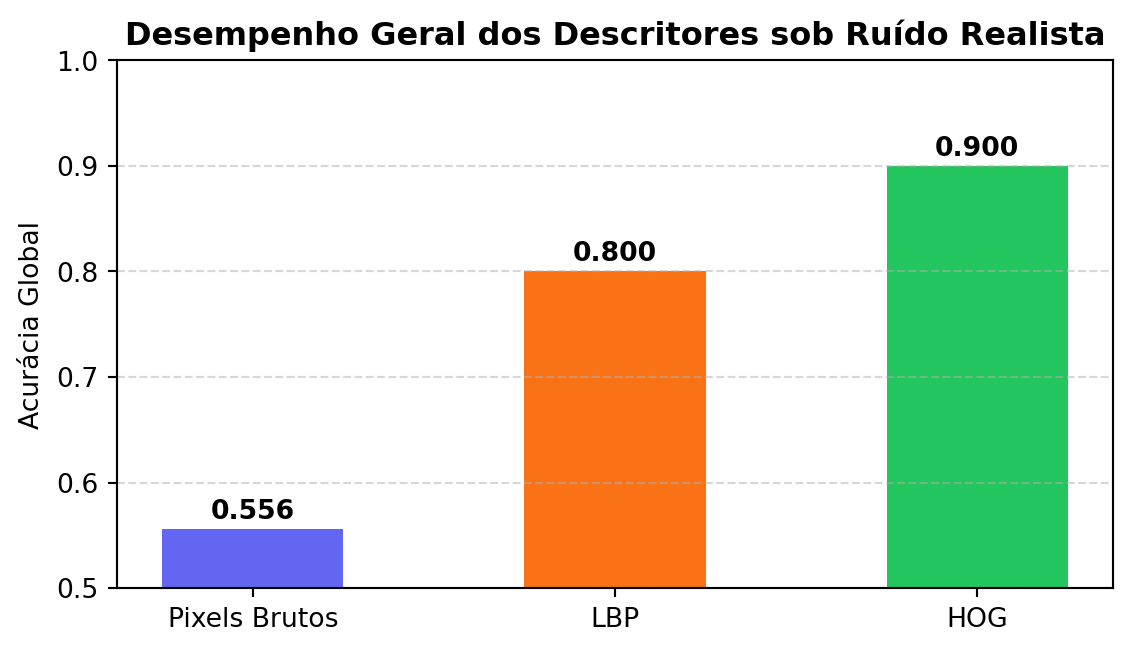

**Figure 7.9:** Detailed comparison of global accuracy in a realistic scenario. Note how structurally extracted descriptors (LBP and HOG) outperform the use of pure raw pixel intensities.


Analysis of results:
- Raw Pixels: Sensitive to local lighting variations and noise.
- LBP: Good tolerance to global monotonic lighting variations.
- HOG: Excellent for contours and stable shapes under small geometric fluctuations.


In [8]:
# Visual comparison in a standalone figure
plt.figure(figsize=(6, 3.5))
nomes = list(resultados.keys())
acuracia = list(resultados.values())
colors = ['#6366f1', '#f97316', '#22c55e']

bars = plt.bar(nomes, acuracia, color=colors, width=0.5)
plt.ylabel('Acurácia Global')
plt.title('Desempenho Geral dos Descritores sob Ruído Realista', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add the values above the bars using standard rounding for display
for bar, val in zip(bars, acuracia):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Analysis of results:")
print("- Raw Pixels: Sensitive to local lighting variations and noise.")
print("- LBP: Good tolerance to global monotonic lighting variations.")
print("- HOG: Excellent for contours and stable shapes under small geometric fluctuations.")

## 7.9 A Concrete Problem: Simulating Fruit Descriptors

Returning to the fruit classification problem presented at the beginning of the chapter, each image can be represented by a feature vector obtained from the extraction of color, texture, and shape descriptors. [Table 7.1](#tbl-descritores-frutas) presents some descriptors frequently used in Computer Vision applications, including techniques introduced in Chapter 3 and in this chapter.

<a id="tbl-descritores-frutas"></a>

**Tabela 7.1:** Set of chromatic, textural, and geometric descriptors used to represent fruit images.

| Feature              | Description                                               |
|----------------------|-----------------------------------------------------------|
| R, G, B              | mean intensity of the red, green, and blue channels       |
| NC                   | mean intensity in grayscale                               |
| LBP                  | texture descriptor (Local Binary Pattern)                 |
| HOG                  | shape descriptor (Histogram of Oriented Gradients)        |
| Area                 | number of pixels in the object                            |
| Perimeter            | contour length                                            |
| Circularity          | measure of how circular the object is                     |
| Width/height ratio   | proportion between the width and height of the region     |


In this example, each image is represented by the vector

$$
X=(R,G,B,\text{LBP},\text{HOG},\text{Área},\text{Perímetro},\text{Circularidade},\text{Razão}).
$$

> ### 📝 Simplification adopted in this table
>
> In practice, LBP and HOG are not scalar values but histograms with dozens or hundreds of components. In this section, each of them is represented by a single value only to simplify the presentation. In real applications, these positions would be replaced by the full components of the respective histograms.

In real applications, not all descriptors contribute equally to distinguishing the classes. Some provide more relevant information, while others may be redundant or poorly discriminative.

To reproduce this scenario in a controlled manner, `make_classification()` from the `scikit-learn` library will be used. The function generates a synthetic dataset whose features can be interpreted as image descriptors, allowing one to define how many of them will be informative for classification.

In this example, ten synthetic features are generated, of which only seven (`n_informative=7`) participate in the separation among the three classes. The remaining ones simulate poorly informative or redundant attributes. [Figure 7.10](#fig-07-make-classification-ilustracao) presents a conceptual representation of this process.

Before introducing the algorithm that will be studied in detail in this chapter, a remark is in order: to identify, among the ten synthetic features, which ones are most discriminative — and thus select two of them for 2D visualization — a *Random Forest* is used only as an auxiliary diagnostic tool. The KNN, the focus of this chapter, is presented next.

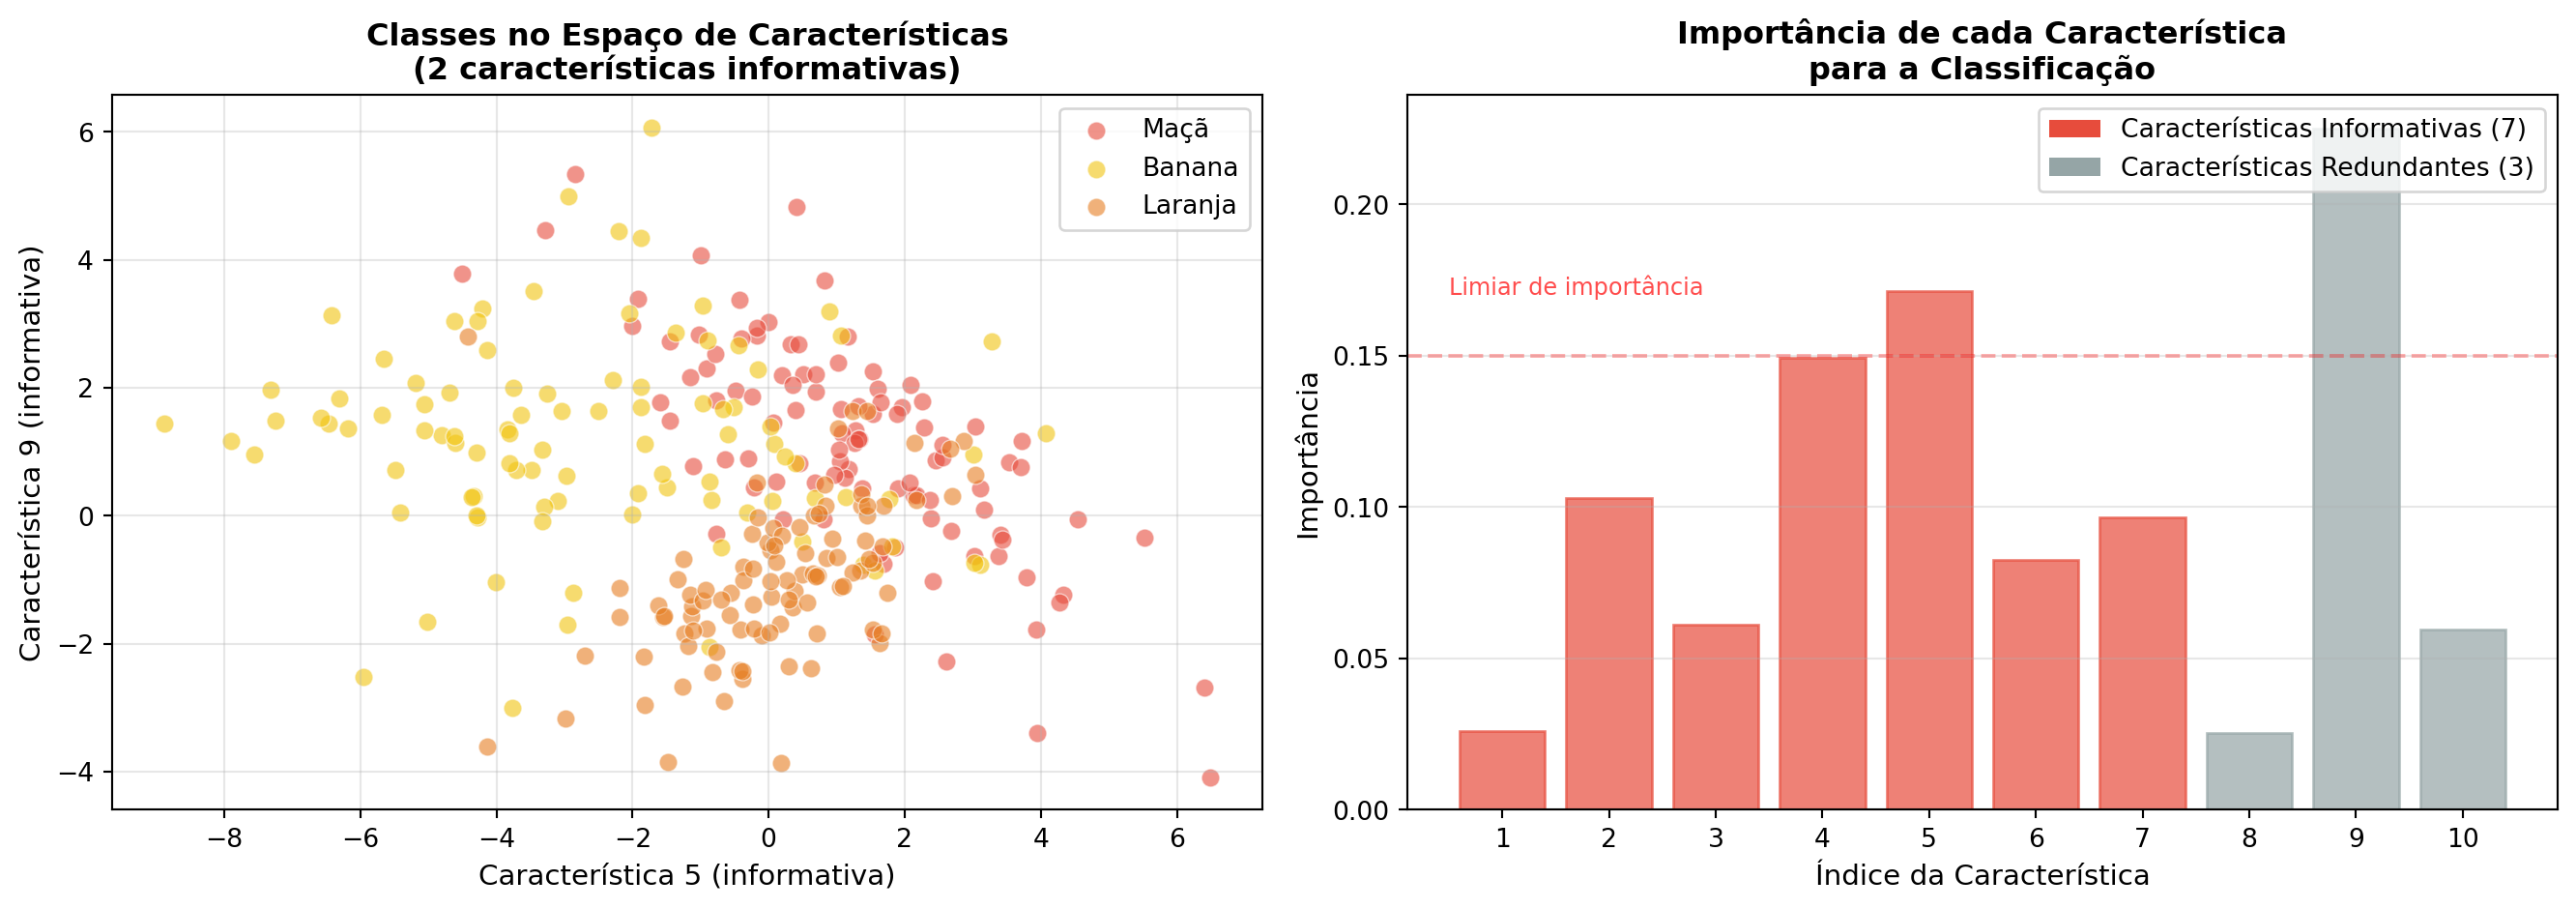

**Figure 7.10:** Illustration of the synthetic data generation process with *make_classification*. On the left, visualization of the three classes in a two-dimensional space formed by two informative features. On the right, relative importance of each feature for classification, showing that only 7 of the 10 features are effectively discriminative, while the others are redundant (2) or duplicated (1).



🔍 Analysis of the generated data:
  • Total samples: 300
  • Number of features: 10
  • Informative features: 7 (columns 1 to 7 of the chart)
  • Redundant features: 2 (columns 8 and 9)
  • Duplicated features: 1 (column 10)
  • Class distribution: [101  98 101]


In [9]:
# Configuration for reproducibility
np.random.seed(42)

# Generation of synthetic data with controlled features
X, y = make_classification(
    n_samples=300,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_repeated=1,        # One feature is a copy of another
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Visualization of classes in 2D (using two informative features)
# Identify which features are most informative
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importancias = rf.feature_importances_
caracteristicas_informativas = np.argsort(importancias)[-2:]  # Two most important

cores = {0: "#e74c3c", 1: "#f1c40f", 2: "#e67e22"}  # Apple, Banana, Orange
rotulos = {0: "Maçã", 1: "Banana", 2: "Laranja"}

for classe in range(3):
    idx = y == classe
    ax1.scatter(X[idx, caracteristicas_informativas[0]], 
               X[idx, caracteristicas_informativas[1]],
               c=cores[classe], label=rotulos[classe], 
               alpha=0.6, s=50, edgecolors="white", linewidth=0.5)

ax1.set_xlabel(f"Característica {caracteristicas_informativas[0]+1} (informativa)", fontsize=11)
ax1.set_ylabel(f"Característica {caracteristicas_informativas[1]+1} (informativa)", fontsize=11)
ax1.set_title("Classes no Espaço de Características\n(2 características informativas)", 
             fontsize=12, fontweight="bold")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Subplot 2: Feature importance
bars = ax2.bar(range(1, 11), importancias, color="#4a90d9", alpha=0.7)
ax2.set_xlabel("Índice da Característica", fontsize=11)
ax2.set_ylabel("Importância", fontsize=11)
ax2.set_title("Importância de cada Característica\npara a Classificação", 
             fontsize=12, fontweight="bold")
ax2.set_xticks(range(1, 11))
ax2.grid(axis="y", alpha=0.3)

# Color bars to highlight features
cores_barras = ["#e74c3c" if i < 7 else "#95a5a6" for i in range(10)]
for bar, cor in zip(bars, cores_barras):
    bar.set_color(cor)

# Add legend
from matplotlib.patches import Patch
legenda_elements = [
    Patch(facecolor="#e74c3c", label="Características Informativas (7)"),
    Patch(facecolor="#95a5a6", label="Características Redundantes (3)")
]
ax2.legend(handles=legenda_elements, loc="upper right")

# Annotate the number of informative features
ax2.axhline(y=0.15, color="red", linestyle="--", alpha=0.3)
ax2.text(0.5, 0.17, "Limiar de importância", fontsize=9, color="red", alpha=0.7)

plt.tight_layout()
plt.show()

print("\n🔍 Analysis of the generated data:")
print(f"  • Total samples: {X.shape[0]}")
print(f"  • Number of features: {X.shape[1]}")
print(f"  • Informative features: 7 (columns 1 to 7 of the chart)")
print(f"  • Redundant features: 2 (columns 8 and 9)")
print(f"  • Duplicated features: 1 (column 10)")
print(f"  • Class distribution: {np.bincount(y)}")

## 7.10 k-NN Classifier: How It Works Internally

The **k-Nearest Neighbors (k-NN)** is one of the simplest and most intuitive classification algorithms in Machine Learning. Unlike many classifiers, it does not explicitly build a model during the training stage. Instead, it stores the labeled samples and, when a new sample needs to be classified, it looks for those that most resemble it.

The algorithm's principle is based on the hypothesis that samples with similar characteristics tend to belong to the same class. To quantify this proximity, k-NN uses a distance measure between feature vectors.

As an example, consider [Table 7.2](#tbl-knn-frutas), which presents a simplified version of the fruit classification problem using only two features: color intensity and circularity, both normalized in the range from 0 to 1.

<a id="tbl-knn-frutas"></a>

**Tabela 7.2:** Simplified example of fruit classification using two normalized features.

| Sample          | Color | Circularity | Class |
|-----------------|------:|------------:|-------|
| Fruit 1         | 0.82  | 0.88        | Apple |
| Fruit 2         | 0.30  | 0.20        | Banana |
| Fruit 3         | 0.88  | 0.85        | Apple |
| Fruit ? (test)  | 0.80  | 0.90        | ?     |


Observing only these two features, one notices that the test fruit is much closer to the samples labeled as **Apple** than to the sample labeled as **Banana**. In the following section, this intuitive notion of proximity will be formalized through a distance metric, used by the algorithm to identify the nearest neighbors and decide the class of the new sample.

### 7.10.1 Distance Metric

The proximity between two samples is typically quantified by the
**Euclidean distance**, defined as

$$
d(x,x_i)=\|x-x_i\|_2=
\sqrt{\sum_{j=1}^{n}(x_j-x_{i,j})^2},
$$

where:

-   $x$ is the test sample;
-   $x_i$ is a sample from the training set;
-   $n$ is the number of features;
-   $x_j$ and $x_{i,j}$ represent the $j$-th feature.

In the implementation of this chapter, $x$ corresponds to a row of `X_test`
and $x_i$ to a row of `X_train`. The `predict()` method automatically
computes the distance between $x$ and all training samples.

In the example from [Table 7.2](#tbl-knn-frutas):

$$
d(\text{test}, \text{Fruit 1}) \approx 0{,}028,\qquad
d(\text{test}, \text{Fruit 2}) \approx 0{,}860,\qquad
d(\text{test}, \text{Fruit 3}) \approx 0{,}094.
$$

Since the smallest distances correspond to Fruits 1 and 3, these samples
will be used in the decision step.

### 7.10.2 Decision Rule

After sorting the distances, the algorithm selects the $k$ nearest
neighbors. Let $N_k(x)$ be this set. The predicted class is given by

$$
\hat y=\operatorname{mode}\{\,y_i:x_i\in N_k(x)\,\},
$$

where $y_i$ is the label of sample $x_i$ and $\hat y$ is the class assigned
to the test sample.

In the example, for $k=3$, the neighbors are Fruit 1 (Apple), Fruit 3 (Apple), and
Fruit 2 (Banana). Since **Apple** receives two votes, this is the predicted
class.

::: callout-tip
### `KNeighborsClassifier` Class

In this chapter, the algorithm is implemented using the
`KNeighborsClassifier` class from the `scikit-learn` library:

``` python
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
```

where:

-   `KNeighborsClassifier(n_neighbors=3)`: sets the value of $k$;
-   `fit(X_train, y_train)`: stores the training samples
    (`X_train`) and their labels (`y_train`);
-   `predict(X_test)`: returns the predicted classes for the samples in
    `X_test`.

Internally, `predict()` performs the steps described earlier:
it calculates the distances, identifies the $k$ nearest neighbors, and
determines the class by majority voting.
:::

[Figure 7.11](#fig-07-knn-passo-passo) illustrates this procedure on a
two-dimensional dataset. The figure highlights the neighbors used in the classification,
while the console displays the algorithm's steps: distance
calculation, sorting, neighbor selection, voting, and class prediction.

1. Distances computed: 30
2. Sorted distances
3. 3 nearest neighbors:
   1.0850 → Classe A
   1.6379 → Classe B
   1.6382 → Classe A
4. Votes: {np.str_('Classe A'): 2, np.str_('Classe B'): 1}
5. Predicted class: Classe A


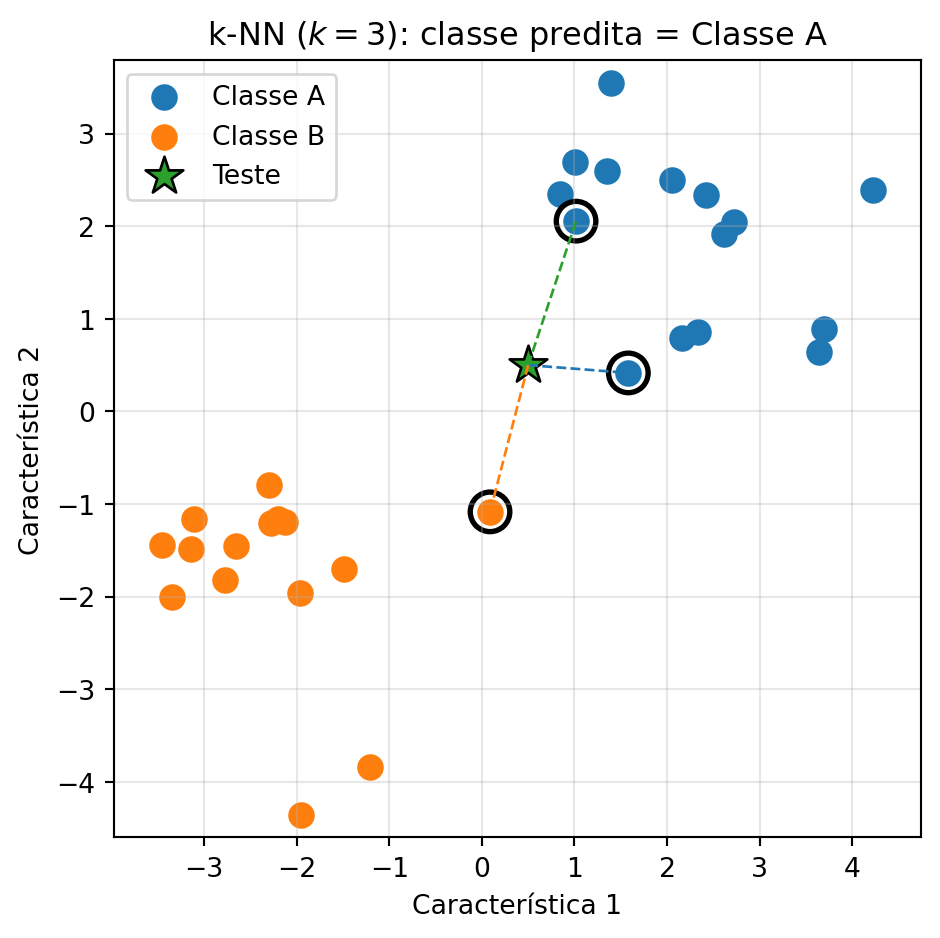

**Figure 7.11:** Classification of a new sample by the k-NN algorithm. The test point (star) is classified using the three nearest neighbors, highlighted by circles.


In [10]:
def knn_passo_a_passo(X, y, x, k=3):
    """Runs the five steps of the k-NN algorithm.
    Parameters: X (training), y (labels), x (test), and k (number of neighbors).
    """
    # 1. Distances
    dist = [(np.linalg.norm(x-xi), yi, i) for i, (xi, yi) in enumerate(zip(X, y))]
    print(f"1. Distances computed: {len(dist)}")

    # 2. Sorting
    dist.sort(key=lambda t: t[0])
    print("2. Sorted distances")

    # 3. Selection
    vizinhos = dist[:k]
    print(f"3. {k} nearest neighbors:")
    for d, c, _ in vizinhos:
        print(f"   {d:.4f} → {c}")

    # 4. Voting
    votos = {}
    for _, c, _ in vizinhos:
        votos[c] = votos.get(c, 0) + 1
    print("4. Votes:", votos)

    # 5. Decision
    classe = max(votos, key=votos.get)
    print("5. Predicted class:", classe)

    return classe, vizinhos


# Example data
np.random.seed(4)
X = np.r_[np.random.randn(15,2)+[2,2],
          np.random.randn(15,2)+[-2,-2]]
y = np.array(["Classe A"]*15 + ["Classe B"]*15)
x = np.array([0.5,0.5])

classe, vizinhos = knn_passo_a_passo(X, y, x)

# Visualization
plt.figure(figsize=(5,5))

for c, rotulo in [("Classe A","Classe A"), ("Classe B","Classe B")]:
    P = X[y==c]
    plt.scatter(P[:,0], P[:,1], s=80, label=rotulo)

plt.scatter(*x, marker="*", s=220, edgecolors="black", label="Teste")

for _, _, i in vizinhos:
    plt.scatter(*X[i], s=220, facecolors="none", edgecolors="black", linewidths=2)
    plt.plot([x[0], X[i,0]], [x[1], X[i,1]], "--", lw=1)

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title(f"k-NN ($k=3$): classe predita = {classe}")
plt.legend()
plt.grid(alpha=.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

### 7.10.3 The Role of the Parameter $k$

The parameter $k$ determines how many neighbors participate in the classification decision.

- **Small values of $k$** (for example, $k=1$) make the classifier more sensitive to noise and local variations, producing more irregular decision boundaries and favoring *overfitting*.
- **Larger values of $k$** produce smoother decision boundaries, but may reduce sensitivity to local structures, favoring *underfitting*.

In problems with two classes, it is common to use odd values of $k$ to reduce the occurrence of ties.

Another important aspect is the **curse of dimensionality**. As the number of features increases, the distances between samples tend to become more similar, making it difficult to identify truly representative neighbors.

::: callout-note
### Summary

The k-NN algorithm can be summarized in three steps:

1. extract the feature vector of the new sample;
2. identify the $k$ nearest neighbors;
3. classify the sample by the most frequent class among those neighbors.

The simulator in [Figure 7.12](#fig-07-sim-07-knn) allows you to visually explore the effect of the parameter $k$ on the decision boundary.
:::

In [11]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-07-knn" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-07-knn * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-07-knn canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; background: #ffffff; cursor: crosshair; margin: 0 auto; }
  #sim-07-knn button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-07-knn button:hover { background: #e8dfcf; }
  #sim-07-knn button.sim-07-knn_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-07-knn input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-07-knn_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-07-knn_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .sim-07-knn_grid_stats { display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px; margin-bottom: 12px; }
  .sim-07-knn_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 10px; text-align: center; }
  .sim-07-knn_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .sim-07-knn_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  .sim-07-knn_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; font-weight: 600; color: #5e5a4a; }
  .sim-07-knn_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(38,36,29,0.2); }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">📌 Simulator: k-NN Decision Boundary</span>
  <span class="sim-07-knn_pill">Click the canvas to add points</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Controles e Estatísticas -->
  <div class="sim-07-knn_panel" style="margin-bottom:14px;">
    
    <div class="sim-07-knn_grid_stats">
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Neighbors (k)</div>
        <div id="sim-07-knn_kVal" class="sim-07-knn_stat_value" style="color:#2980b9;">3</div>
      </div>
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Blue Class</div>
        <div id="sim-07-knn_nAzul" class="sim-07-knn_stat_value" style="color:#2980b9;">0</div>
      </div>
      <div class="sim-07-knn_stat_box">
        <div class="sim-07-knn_stat_label">Red Class</div>
        <div id="sim-07-knn_nVerm" class="sim-07-knn_stat_value" style="color:#c0392b;">0</div>
      </div>
    </div>

    <!-- Botões de Ação -->
    <div style="display:flex; gap:6px; flex-wrap:wrap; margin-bottom:12px; justify-content:center;">
      <button id="sim-07-knn_btnAzul" class="sim-07-knn_active">🔵 Add Blue</button>
      <button id="sim-07-knn_btnVerm">🔴 Add Red</button>
      <button id="sim-07-knn_btnLimpar" style="border-color:#f5b7b1; color:#c0392b; background:#fdecea;">🗑️ Clear</button>
      <button id="sim-07-knn_btnReset">↺ Reset</button>
    </div>

    <!-- Slider k -->
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:6px;">
      <label style="font-size:11px; font-weight:700; color:#5e5a4a;">
        k value: <span id="sim-07-knn_slVal" style="font-family:monospace; color:#26241d;">3</span>
      </label>
    </div>
    <input type="range" id="sim-07-knn_slider" min="1" max="15" step="1" value="3">

  </div>

  <!-- Canvas -->
  <div style="margin-bottom:14px; text-align:center;">
    <canvas id="sim-07-knn_canvas" width="640" height="360"></canvas>
  </div>

  <!-- Legenda e Rodapé -->
  <div class="sim-07-knn_panel">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
      <div style="display:flex; gap:16px;">
        <div class="sim-07-knn_legend"><span class="sim-07-knn_dot" style="background:#2980b9;"></span> Blue Class</div>
        <div class="sim-07-knn_legend"><span class="sim-07-knn_dot" style="background:#c0392b;"></span> Red Class</div>
      </div>
      <div style="font-size:10.5px; color:#8a8371; font-weight:600;">
        The colored background region represents the class assigned by the algorithm to each point in the space.
      </div>
    </div>
  </div>

</div>
</div>

<script>
(function(){
  function initSim07Knn(root){
    if (!root || root.dataset.sim07KnnInit) return;
    root.dataset.sim07KnnInit = "1";

    const canvas = root.querySelector("#sim-07-knn_canvas");
    const ctx = canvas.getContext("2d");
    const W = canvas.width, H = canvas.height;
    const CELL = 10;

    let currentLabel = 0; // 0 = azul, 1 = vermelho
    let kVal = 3;
    let points = [];

    function defaultPoints(){
      return [
        {x:120,y:260,l:0},{x:150,y:230,l:0},{x:100,y:200,l:0},{x:160,y:290,l:0},
        {x:90,y:250,l:0},{x:140,y:190,l:0},{x:175,y:250,l:0},{x:110,y:150,l:0},
        {x:200,y:230,l:0},{x:130,y:310,l:0},
        {x:480,y:100,l:1},{x:450,y:130,l:1},{x:500,y:160,l:1},{x:440,y:80,l:1},
        {x:510,y:110,l:1},{x:470,y:60,l:1},{x:430,y:150,l:1},{x:520,y:190,l:1},
        {x:490,y:220,l:1},{x:460,y:190,l:1},
        {x:300,y:170,l:0},{x:320,y:190,l:1},{x:280,y:200,l:1},{x:310,y:150,l:0}
      ];
    }

    function classify(x, y, k, pontos){
      if (pontos.length === 0) return null;
      const dists = pontos.map(p => ({
        d: (p.x - x) * (p.x - x) + (p.y - y) * (p.y - y),
        l: p.l
      }));
      dists.sort((a, b) => a.d - b.d);
      const vizinhos = dists.slice(0, Math.min(k, dists.length));
      let votos = [0, 0];
      vizinhos.forEach(v => votos[v.l]++);
      return votos[1] > votos[0] ? 1 : 0;
    }

    function render(){
      ctx.clearRect(0, 0, W, H);

      // Região de decisão em grade
      for (let gy = 0; gy < H; gy += CELL){
        for (let gx = 0; gx < W; gx += CELL){
          const cx = gx + CELL / 2, cy = gy + CELL / 2;
          const classe = points.length > 0 ? classify(cx, cy, kVal, points) : null;
          if (classe === 0) ctx.fillStyle = "rgba(41, 128, 185, 0.15)";
          else if (classe === 1) ctx.fillStyle = "rgba(192, 57, 43, 0.15)";
          else ctx.fillStyle = "#fafaf7";
          ctx.fillRect(gx, gy, CELL, CELL);
        }
      }

      // Desenhar pontos de treinamento
      points.forEach(p => {
        ctx.beginPath();
        ctx.arc(p.x, p.y, 6.5, 0, 2 * Math.PI);
        ctx.fillStyle = p.l === 0 ? "#2980b9" : "#c0392b";
        ctx.fill();
        ctx.lineWidth = 1.5;
        ctx.strokeStyle = "#ffffff";
        ctx.stroke();
      });

      root.querySelector("#sim-07-knn_nAzul").textContent = points.filter(p => p.l === 0).length;
      root.querySelector("#sim-07-knn_nVerm").textContent = points.filter(p => p.l === 1).length;
      root.querySelector("#sim-07-knn_kVal").textContent = kVal;
    }

    canvas.addEventListener("click", function(ev){
      const rect = canvas.getBoundingClientRect();
      const scaleX = canvas.width / rect.width;
      const scaleY = canvas.height / rect.height;
      const x = (ev.clientX - rect.left) * scaleX;
      const y = (ev.clientY - rect.top) * scaleY;
      points.push({x: x, y: y, l: currentLabel});
      render();
    });

    root.querySelector("#sim-07-knn_slider").addEventListener("input", function(ev){
      kVal = parseInt(ev.target.value, 10);
      root.querySelector("#sim-07-knn_slVal").textContent = kVal;
      render();
    });

    const btnAzul = root.querySelector("#sim-07-knn_btnAzul");
    const btnVerm = root.querySelector("#sim-07-knn_btnVerm");

    function setLabel(l){
      currentLabel = l;
      btnAzul.classList.toggle("sim-07-knn_active", l === 0);
      btnVerm.classList.toggle("sim-07-knn_active", l === 1);
    }

    btnAzul.addEventListener("click", function(){ setLabel(0); });
    btnVerm.addEventListener("click", function(){ setLabel(1); });

    root.querySelector("#sim-07-knn_btnLimpar").addEventListener("click", function(){
      points = [];
      render();
    });

    root.querySelector("#sim-07-knn_btnReset").addEventListener("click", function(){
      points = defaultPoints();
      render();
    });

    setLabel(0);
    points = defaultPoints();
    render();
  }

  function tryInitSim07Knn(){
    var root = document.getElementById("sim-07-knn");
    if (root) initSim07Knn(root); else setTimeout(tryInitSim07Knn, 200);
  }
  tryInitSim07Knn();
})();
</script>
</div>
""")

**Figure 7.12:** Interactive simulator of the k-NN decision boundary: add training points and adjust the value of k to observe the effect on the decision region.


## 7.11 Practical Project 1: Handwritten Digit Classification with k-NN

The previous sections presented the k-NN algorithm through a simplified fruit classification example, using only two features. Next, the same algorithm is applied to an image dataset, in which each sample is represented by a higher-dimensional vector.

As a case study, the public `load_digits` database, provided by the `scikit-learn` library, is used. This dataset contains 1797 images of handwritten digits from classes 0 to 9, each with a resolution of $8 \times 8$ pixels in grayscale. Each image is represented by a vector with 64 features, corresponding to pixel intensities, and each vector has a label indicating the corresponding digit.

The `load_digits` database is provided by the `scikit-learn` library and is used in this chapter to illustrate the application of the k-NN algorithm. In addition to being available directly in `scikit-learn`, it eliminates the need for additional steps of data acquisition and preparation, allowing attention to be focused on the implementation and evaluation of the classifier.

[Figure 7.13](#fig-07-digits-amostra) presents a sample of the images from the database.

Total samples: 1797, vector dimension: 64
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


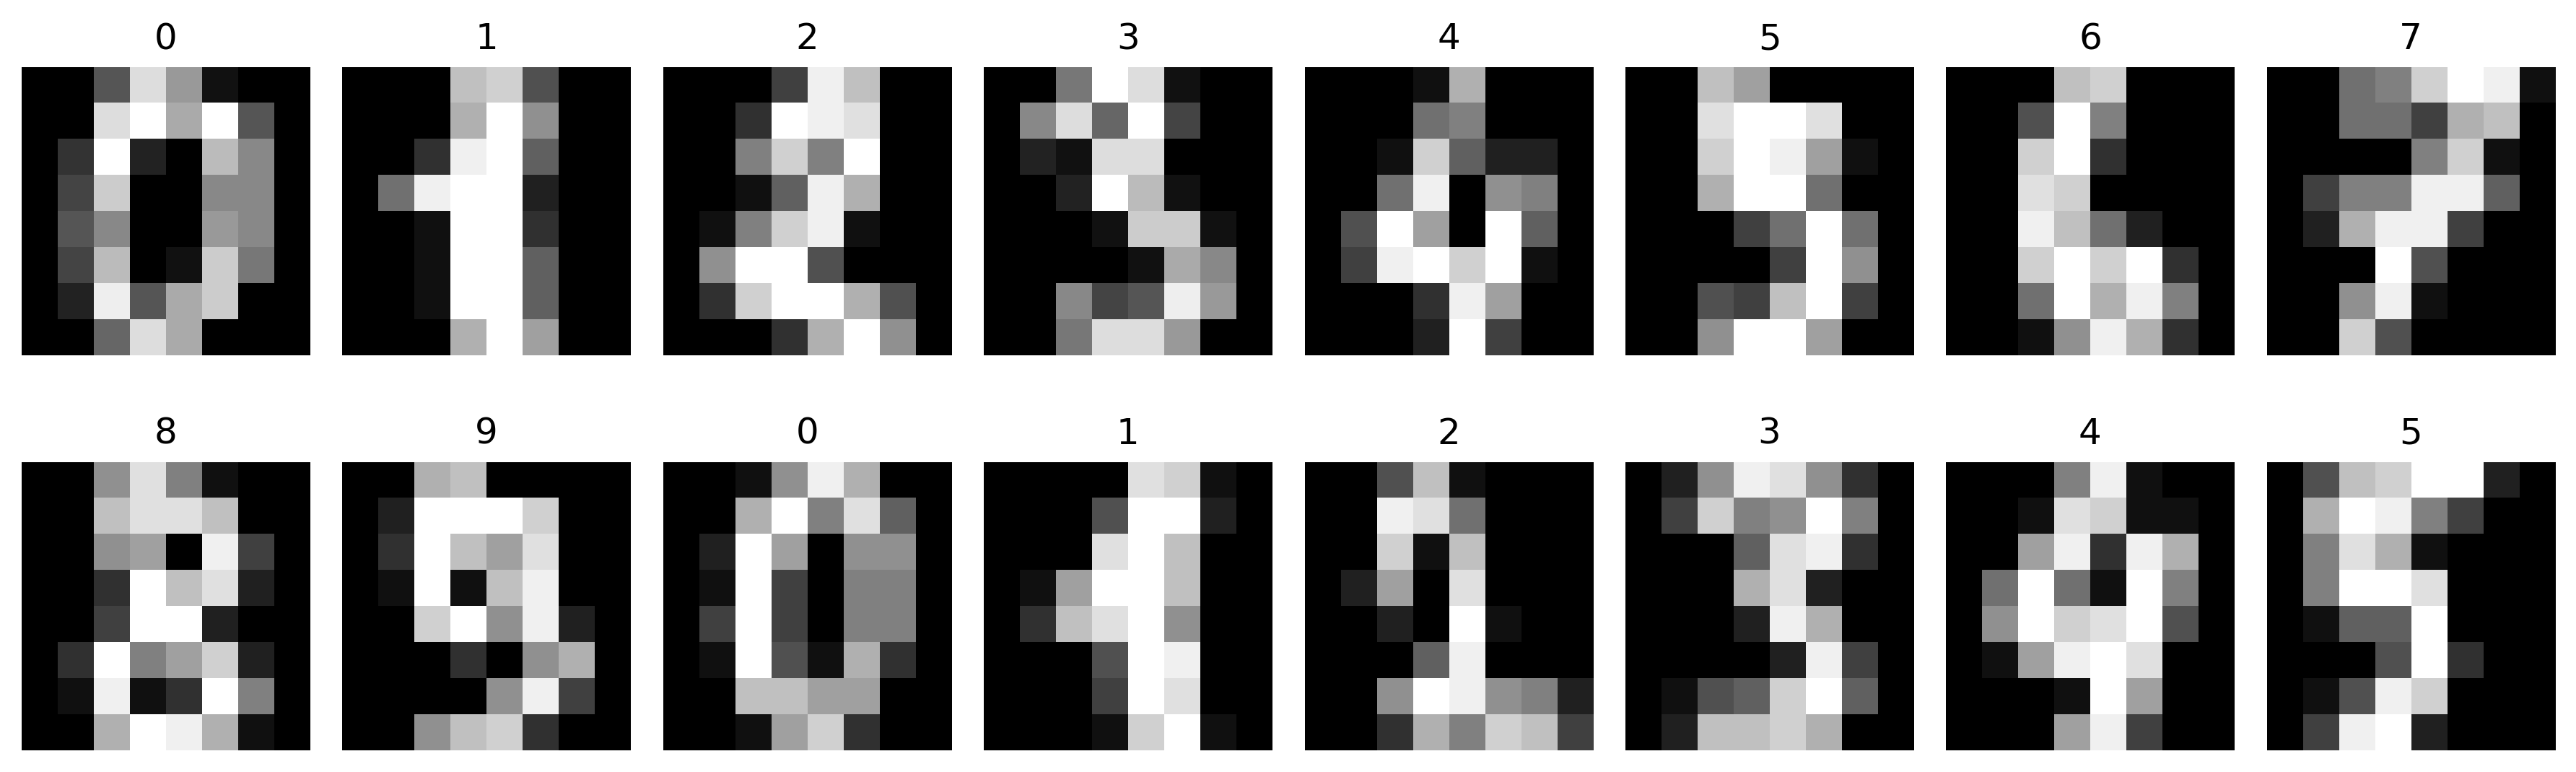

**Figure 7.13:** Sample of handwritten digits from the *load_digits* dataset, used as a classification case study.


In [12]:
digits = load_digits()
print(f"Total samples: {digits.data.shape[0]}, vector dimension: {digits.data.shape[1]}")
print(f"Classes: {[int(i) for i in sorted(set(digits.target))]}")

n_amostras = 16
imgs = list(digits.images[:n_amostras])
imgs_titles = [str(label) for label in digits.target[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=8, figsize=(12, 4))


### 7.11.1 Classification with Intensity Vectors

In this first experiment, each $8 \times 8$ image is represented directly by the intensities of its 64 pixels, without extracting additional descriptors. Thus, each sample corresponds to a vector of 64 features, used as input to the k-NN classifier.

Next, the dataset is divided into training and test subsets, preserving the proportion of the ten classes through the parameter `stratify=y`. The classifier is trained with $k=3$ and evaluated on the test set using accuracy and the confusion matrix shown in [Figure 7.14](#fig-07-knn-pixels).

Accuracy (intensity vectors, k=3): 0.9870


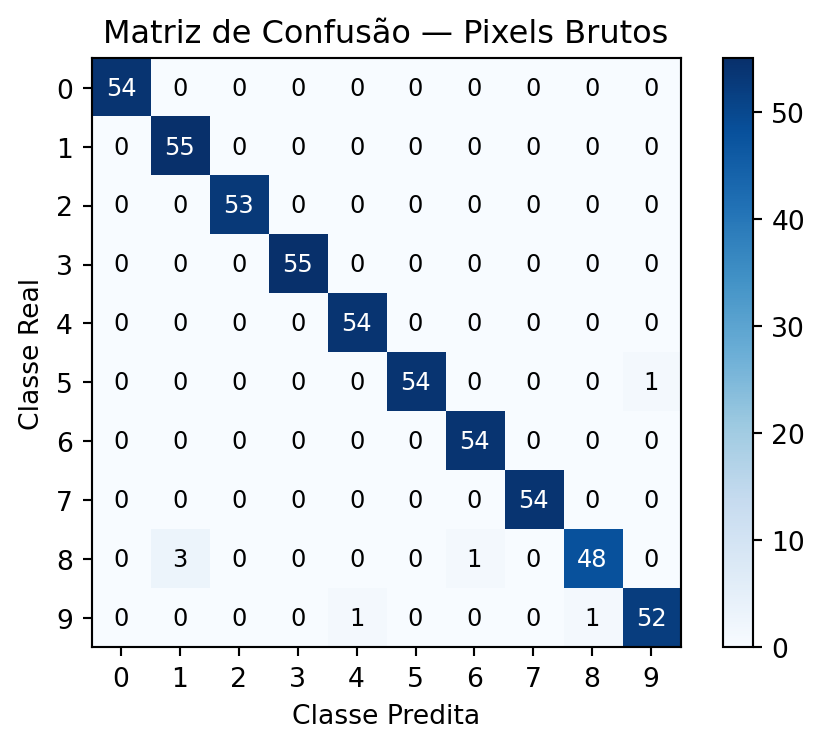

**Figure 7.14:** Confusion matrix of the k-NN classifier trained with raw intensity vectors (pixels).


In [13]:
X, y = digits.data, digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_pixels = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_pixels.fit(X_treino, y_treino)
pred_pixels = knn_pixels.predict(X_teste)

acc_pixels = accuracy_score(y_teste, pred_pixels)
print(f"Accuracy (intensity vectors, k={n_neighbors}): {acc_pixels:.4f}")

cm = confusion_matrix(y_teste, pred_pixels)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=9
        )

plt.title("Matriz de Confusão — Pixels Brutos")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()


### 7.11.2 Classification with HOG Descriptors

In the previous experiment, each image was represented directly by the intensities of its pixels. In this section, this representation is replaced by HOG descriptors (*Histogram of Oriented Gradients*), which encode information about the distribution of gradient orientations in the image.

The same data partitioning, the same k-NN classifier, and the same evaluation protocol are maintained, with only the image representation being changed. [Figure 7.15](#fig-07-comparativo-descritores) compares the results obtained with intensity vectors and with HOG descriptors.

HOG vector dimension: 32
Accuracy (HOG descriptor, k=3): 0.7593


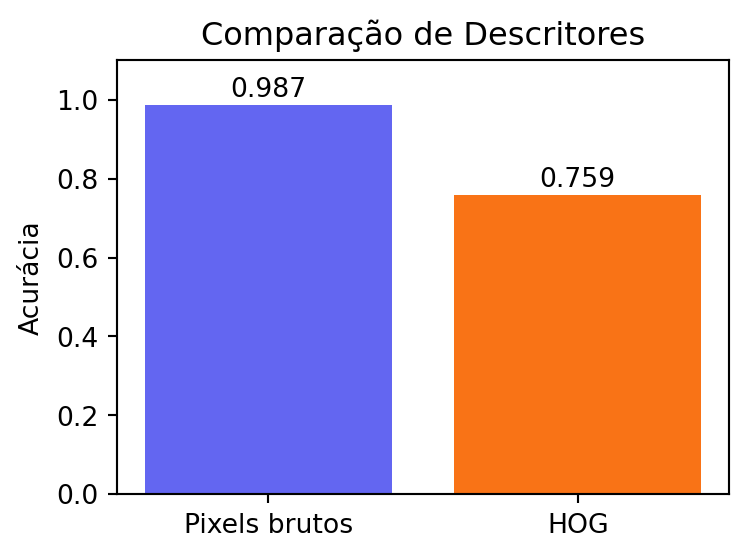

**Figure 7.15:** Comparison of accuracy between raw pixel descriptors and HOG for the k-NN classifier (k=3) on the digits dataset.


In [14]:
descritores_hog = np.array([
    hog(img, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(1, 1))
    for img in digits.images
])
print(f"HOG vector dimension: {descritores_hog.shape[1]}")

Xh_treino, Xh_teste, yh_treino, yh_teste = train_test_split(
    descritores_hog, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_hog = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_hog.fit(Xh_treino, yh_treino)
pred_hog = knn_hog.predict(Xh_teste)
acc_hog = accuracy_score(yh_teste, pred_hog)
print(f"Accuracy (HOG descriptor, k={n_neighbors}): {acc_hog:.4f}")

plt.figure(figsize=(4, 3))
plt.bar(["Pixels brutos", "HOG"], [acc_pixels, acc_hog], color=["#6366f1", "#f97316"])
plt.ylim(0, 1.1)  # Increases the upper limit to give space
plt.ylabel("Acurácia")
plt.title("Comparação de Descritores")
for i, v in enumerate([acc_pixels, acc_hog]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")  # Increases the vertical offset
plt.tight_layout()

> ### 📝 Why does this happen?
>
> In [Figure 7.15](#fig-07-comparativo-descritores), the classifier trained with **pixel intensity** vectors achieves higher accuracy ($0.987$) than the one based on **HOG** descriptors ($0.759$). This result is related to the characteristics of the `load_digits` dataset.
>
> The images have a resolution of only $8\times8$ pixels, are approximately centered, and exhibit little variation in illumination, scale, and orientation. In this scenario, pixel intensities preserve virtually all the information needed to distinguish the classes. In contrast, HOG summarizes the image into histograms of gradient orientations, reducing part of the spatial detail available in the original pixels.
>
> This reduction in information can make it harder to separate visually similar digits, such as 3 and 8 or 4 and 9, especially when the image resolution is low.
>
> In problems with higher-resolution images or those subject to variations in illumination, position, scale, or small deformations, descriptors such as HOG tend to better represent the local structure of the image than individual pixel values. Thus, this experiment illustrates an important principle of Machine Learning: **the data representation should be chosen according to the characteristics of the problem, not by the complexity of the descriptor.**

## 7.12 Classifier Evaluation

In the previous sections, the quality of the classifier was analyzed
through accuracy and the confusion matrix. In this section, these tools
are complemented by metrics used in model evaluation and by a
procedure for selecting the value of the parameter $k$.

Accuracy corresponds to the proportion of correctly classified
samples. Although it is a simple and widely used measure, it
may be insufficient when classes exhibit highly imbalanced
distributions.

From the confusion matrix — introduced in **Chapter 1** and
used throughout this chapter — class-specific metrics can be
calculated, such as precision and recall:

$$
\text{Precision}=\frac{TP}{TP+FP},
\qquad
\text{Recall}=\frac{TP}{TP+FN},
$$

where $TP$, $FP$, and $FN$ represent, respectively, the number of
true positives, false positives, and false negatives for the class
under analysis. Precision quantifies the proportion of correct positive
predictions, while recall measures the classifier's ability to
identify examples belonging to the class.

### 7.12.1 Choosing $k$ by Cross-Validation

In the previous experiments, $k=3$ was adopted to illustrate how the algorithm works. However, this parameter directly influences the classifier's performance and, in practice, should be selected based on the data.

A widely used approach is **cross-validation**, in which the training set is divided into successive partitions to estimate the model's performance on data not used during training.

The following code computes the average accuracy obtained by five-fold cross-validation for different values of $k$. The results are presented in [Figure 7.16](#fig-07-elbow-k), allowing the identification of the region where the classifier achieves its best performance.

Best k value found: 2 (mean accuracy=0.9672)


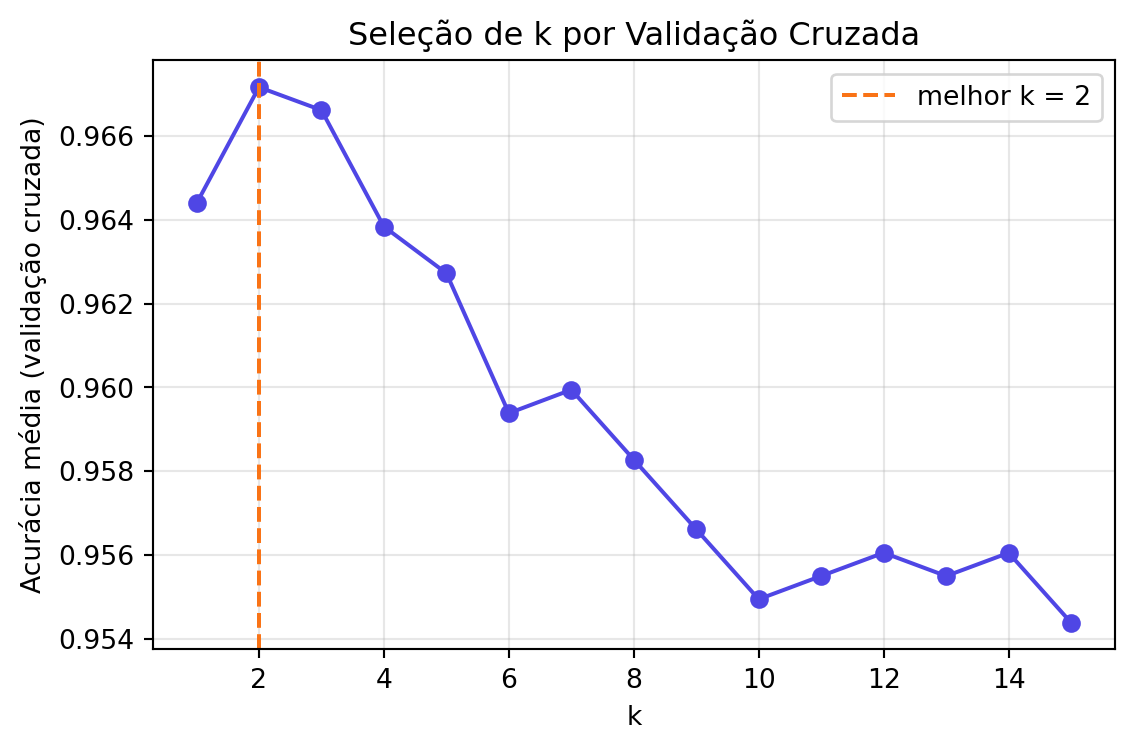

**Figure 7.16:** Mean accuracy by cross-validation (5 folds) as a function of parameter k, for the digit base with raw intensity vectors.


In [15]:
valores_k = range(1, 16)
acuracias_medias = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X, y, cv=5)
    acuracias_medias.append(scores.mean())

melhor_k = list(valores_k)[int(np.argmax(acuracias_medias))]
print(f"Best k value found: {melhor_k} (mean accuracy={max(acuracias_medias):.4f})")

plt.figure(figsize=(6, 4))
plt.plot(list(valores_k), acuracias_medias, marker="o", color="#4f46e5")
plt.axvline(melhor_k, color="#f97316", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k")
plt.ylabel("Acurácia média (validação cruzada)")
plt.title("Seleção de k por Validação Cruzada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

### 7.12.2 The Bias-Variance Trade-off: Diagnosing *Overfitting* and *Underfitting*

The hyperparameter $k$ influences the complexity of the k-NN classifier's decision boundary and, consequently, its generalization capability. In general terms, small values of $k$ make the model more sensitive to training samples, while larger values produce smoother decision boundaries.

These behaviors are associated with the trade-off between **bias** and **variance**. Very small values of $k$ tend to increase the risk of **overfitting**, especially in noisy datasets, whereas very large values can lead to **underfitting**, reducing the model's ability to capture local data structures.

While [Figure 7.16](#fig-07-elbow-k) presented only the average accuracy obtained through cross-validation, [Figure 7.17](#fig-07-overfitting-analysis) compares training and test accuracies for different values of $k$. The highlighted regions in the plot represent the algorithm's expected behavior: a higher risk of overfitting for small values of $k$, an intermediate region that often yields a good balance between bias and variance, and a higher risk of underfitting for large values of $k$.

However, these regions should be interpreted only as a conceptual reference. The observed behavior depends on the characteristics of the dataset. In the `load_digits` dataset, for example, the images exhibit low variability and good class separation, so small values of $k$ may perform similarly—or even better—than others, without showing significant overfitting.

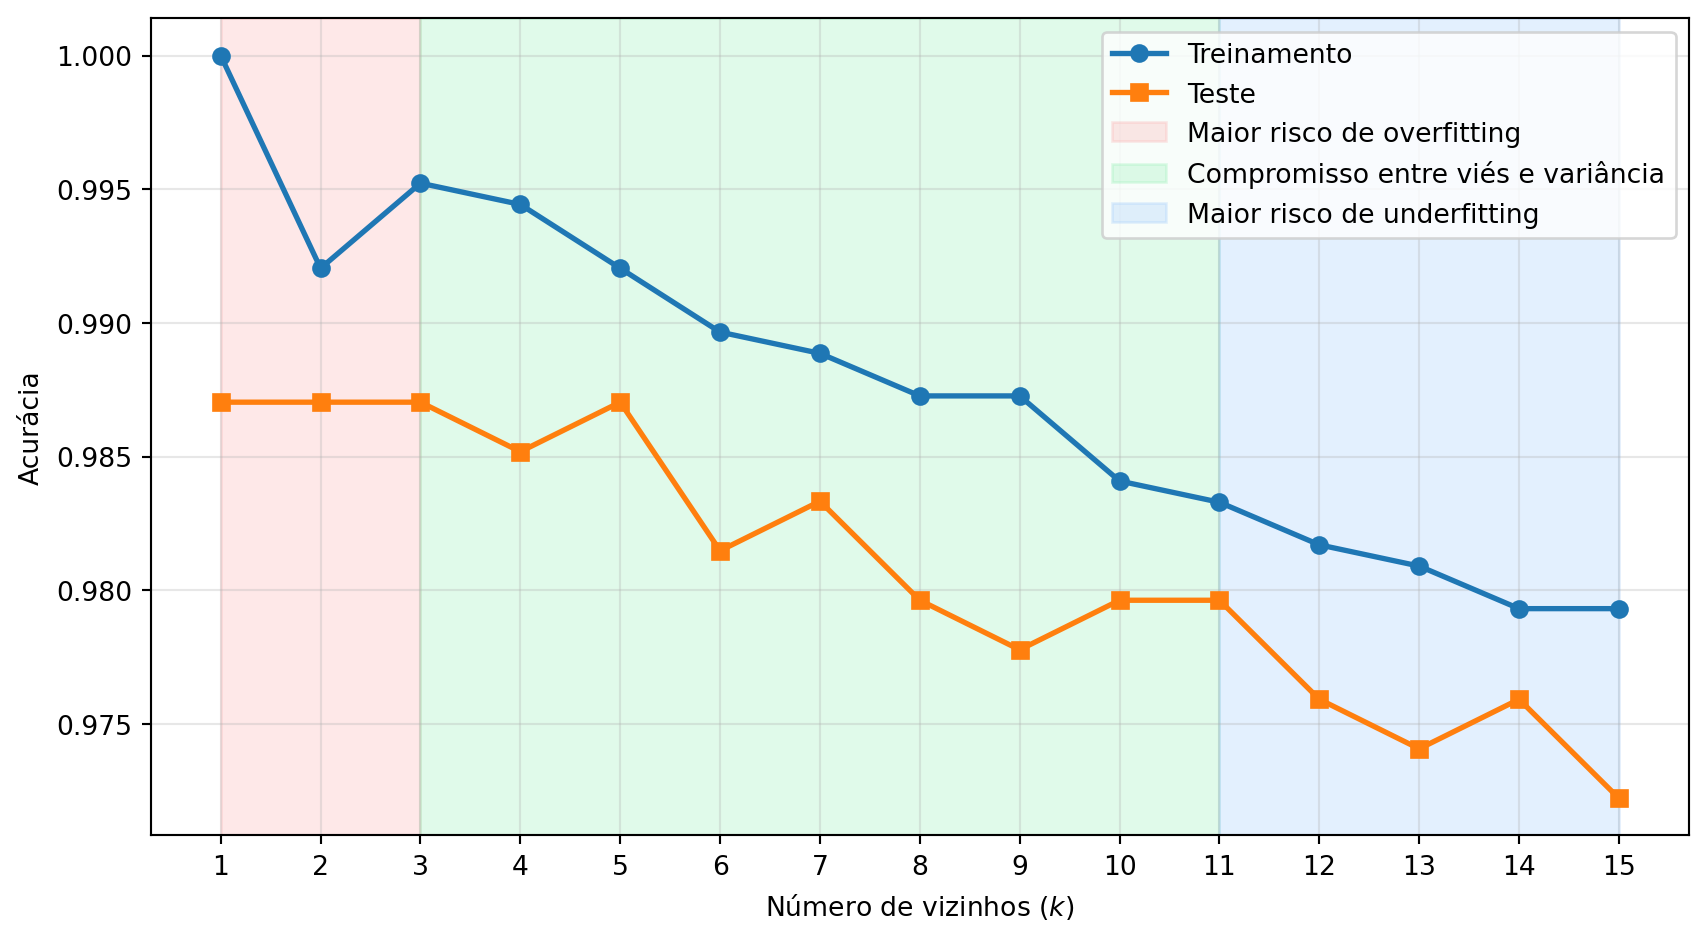

**Figure 7.17:** Accuracy on the training and test sets for different values of $k$. The colored regions represent, conceptually, behavior trends of the classifier: higher risk of overfitting (red), bias-variance trade-off (green) and higher risk of underfitting (blue).


Interpretation
- Small k values: higher risk of overfitting.
- Intermediate values: better bias-variance trade-off.
- Large k values: higher risk of underfitting.

The colored regions represent general trends;
the observed behavior depends on the dataset.

Highest test accuracy: 0.987
k values that achieved this accuracy: [1, 2, 3, 5]


In [16]:
k_values = range(1, 16)
train_acc, test_acc = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_treino, y_treino)
    train_acc.append(accuracy_score(y_treino, knn.predict(X_treino)))
    test_acc.append(accuracy_score(y_teste, knn.predict(X_teste)))

plt.figure(figsize=(9,5))
plt.plot(k_values, train_acc, "o-", lw=2, label="Treinamento")
plt.plot(k_values, test_acc,  "s-", lw=2, label="Teste")

plt.axvspan(1, 3,  color="#fca5a5", alpha=.25, label="Maior risco de overfitting")
plt.axvspan(3,11,  color="#86efac", alpha=.25, label="Compromisso entre viés e variância")
plt.axvspan(11,15, color="#93c5fd", alpha=.25, label="Maior risco de underfitting")

plt.xlabel("Número de vizinhos ($k$)")
plt.ylabel("Acurácia")
plt.xticks(k_values)
plt.grid(alpha=.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

maior_acc = max(test_acc)
melhores_k = [k for k, a in zip(k_values, test_acc) if np.isclose(a, maior_acc)]

print("Interpretation")
print("- Small k values: higher risk of overfitting.")
print("- Intermediate values: better bias-variance trade-off.")
print("- Large k values: higher risk of underfitting.")
print("\nThe colored regions represent general trends;")
print("the observed behavior depends on the dataset.")
print(f"\nHighest test accuracy: {maior_acc:.3f}")
print(f"k values that achieved this accuracy: {melhores_k}")

## 7.13 Practical Project 2: Comparison of Descriptors for Texture Classification

In **Chapter 6**, local variance was used as a texture descriptor to **detect** anomalies in industrial surfaces, distinguishing **conforming** and **defective** samples. In this project, the problem is reformulated as a **multiclass classification** task, in which different image representations are used as input to a classifier.

Three types of descriptors will be considered: **pixel intensities**, **Local Binary Patterns (LBP)**, and **Histogram of Oriented Gradients (HOG)**. For each representation, a feature vector will be extracted to serve as input for the $k$-nearest neighbors ($k$-NN) algorithm. Finally, the accuracies obtained by each descriptor under the conditions defined for this experiment will be compared.

The evaluation will be carried out through **five-fold stratified cross-validation**. In this procedure, the dataset is divided into five subsets while preserving the proportion between classes. In each iteration, one partition is used for testing and the remaining four for training, repeating the process until all partitions have been used as the test set. At the end of the five runs, the mean accuracy and standard deviation are calculated for each descriptor.

The dataset consists of three classes of synthetic textures: **granular**, obtained from smoothed Gaussian noise; **striped**, formed by periodic sinusoidal patterns; and **blotched**, composed of overlapping circular regions. To introduce variability among samples, all images receive a low-intensity Gaussian noise perturbation. [Figure 7.18](#fig-07-texturas-amostra) presents examples of the three classes used in the experiment.

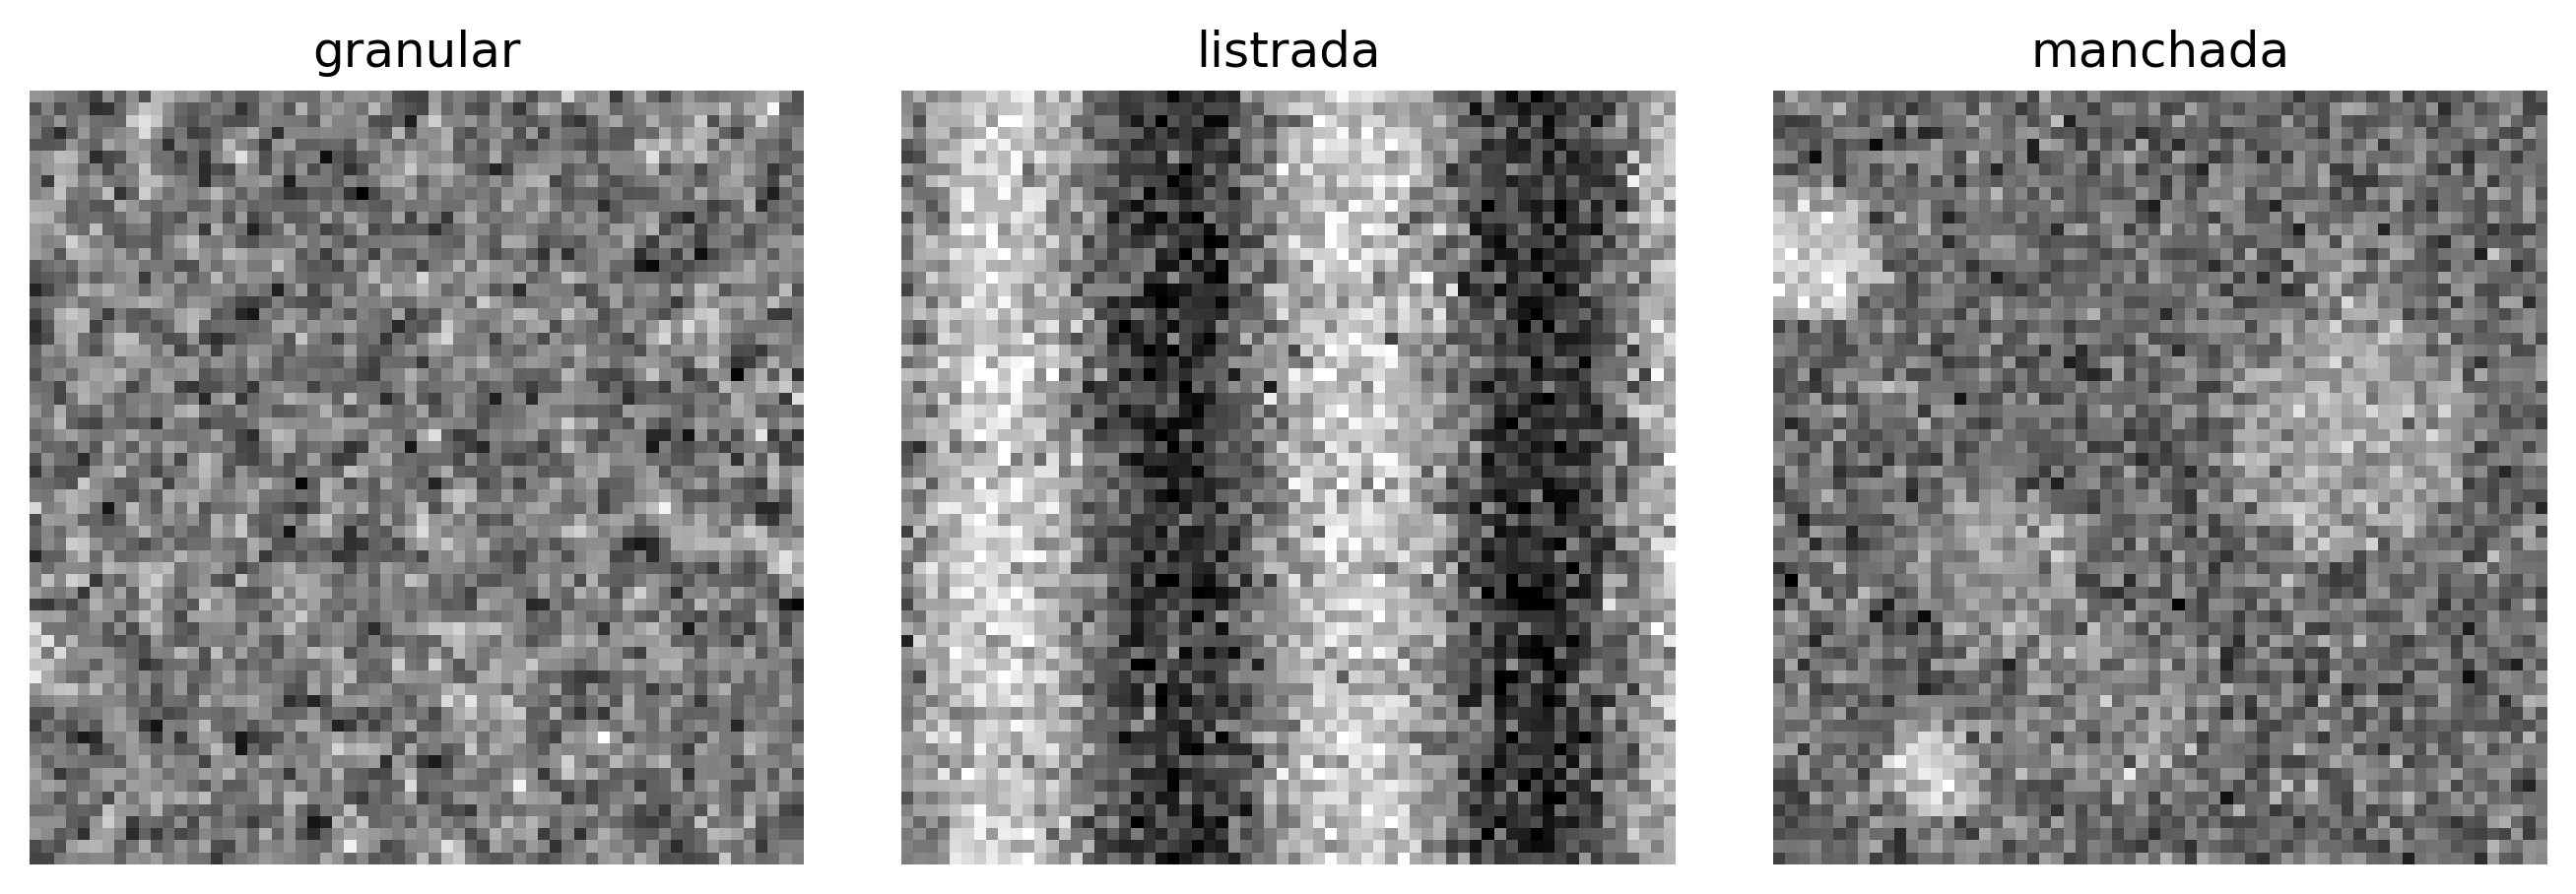

**Figure 7.18:** Synthetic samples of the three texture classes used in the classification experiment, generated with Gaussian noise and intra-class variability.


In [17]:
rng = np.random.default_rng(42)

def gerar_textura(classe, tamanho=64, ruido=0.10):
    """Generates a synthetic 64x64 texture belonging to one of the three classes."""
    if classe == "granular":
        escala = rng.uniform(0.14, 0.22)
        img = rng.normal(0.5, escala, (tamanho, tamanho))
        img = cv2.GaussianBlur(img.astype(np.float32), (3, 3), 0)

    elif classe == "listrada":
        n_periodos = rng.uniform(4, 8)
        amplitude = rng.uniform(0.22, 0.38)
        eixo_x = np.linspace(0, n_periodos * np.pi, tamanho)
        base = 0.5 + amplitude * np.sin(eixo_x)
        img = np.tile(base, (tamanho, 1)).astype(np.float32)
        img += rng.normal(0, 0.09, (tamanho, tamanho)).astype(np.float32)

    elif classe == "manchada":
        img = np.full((tamanho, tamanho), 0.5, dtype=np.float32)
        n_manchas = rng.integers(5, 11)
        for _ in range(n_manchas):
            cx, cy = rng.integers(0, tamanho, 2)
            raio = int(rng.integers(3, 11))
            intensidade = float(rng.uniform(0.15, 0.9))
            cv2.circle(img, (int(cx), int(cy)), raio, intensidade, -1)
        img = cv2.GaussianBlur(img, (5, 5), 0)

    else:
        raise ValueError(f"Classe desconhecida: {classe}")

    img = img + rng.normal(0, ruido, (tamanho, tamanho)).astype(np.float32)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

classes_textura = ["granular", "listrada", "manchada"]
amostras = [gerar_textura(c) for c in classes_textura]

mm.show(amostras, titles=classes_textura, cols=3, figsize=(9, 3))

### 7.13.1 Feature Extraction Pipeline and Comparative Evaluation

To compare the performance of different image representation approaches, a balanced dataset containing 60 samples per class was generated. From this dataset, three types of feature vectors were extracted, each representing distinct aspects of visual information:

1. **Raw pixels**: vector obtained by flattening the image intensity matrix, resulting in a vector of $64 \times 64 = 4096$ attributes;
2. **Uniform LBP histogram**: normalized histogram of the frequencies of local patterns produced by the uniform LBP operator, comprising 10 attributes;
3. **HOG descriptor**: vector formed by histograms of oriented gradients, which represent the spatial distribution of edge orientations, totaling 128 attributes.

Since these descriptors have distinct scales and dimensionalities, the feature vectors are standardized using the `StandardScaler`, so that each attribute has zero mean and unit standard deviation. This step prevents attributes with larger magnitudes from disproportionately influencing the Euclidean distance calculation employed by the classifier.

The evaluation is performed using the $k$-NN algorithm with $k=5$, under the same stratified five-fold cross-validation protocol described in the previous section. The average accuracy obtained across the five runs, see [Figure 7.19](#fig-07-comparativo-kfolds), provides a more stable estimate of the classifier's performance, reducing the dependence on a single training–test split.

Pixels Brutos   -> Average Accuracy: 0.6889 (± 0.0478)
LBP (Textura)   -> Average Accuracy: 0.7611 (± 0.0648)
HOG (Forma)     -> Average Accuracy: 0.4889 (± 0.0624)


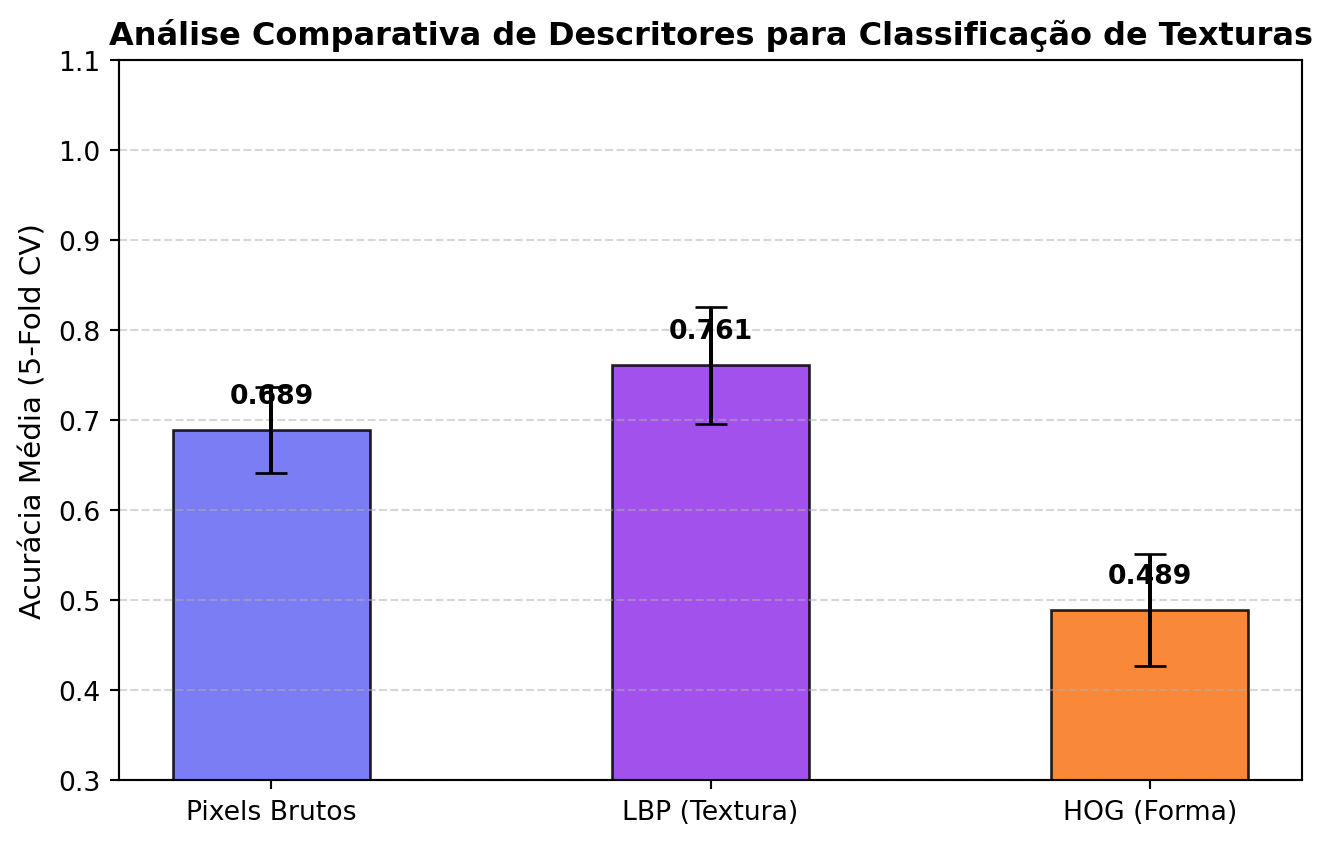

**Figure 7.19:** Average accuracy obtained via cross-validation (5-fold) for the descriptors of Raw Pixels, LBP, and HOG applied to the synthetic textures dataset.


In [18]:
rng = np.random.default_rng(42)

# 1. Dataset generation
X_bruto, X_lbp, X_hog, y_textura = [], [], [], []

for classe in classes_textura:
    for _ in range(60):
        img = gerar_textura(classe, ruido=0.10)
        
        # Extraction 1: Raw pixels
        X_bruto.append(img.ravel())
        
        # Extraction 2: Uniform LBP histogram
        lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
        hist_lbp, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
        X_lbp.append(hist_lbp)
        
        # Extraction 3: HOG descriptor
        feat_hog = hog(img, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
        X_hog.append(feat_hog)
        
        y_textura.append(classe)

y_textura = np.array(y_textura)
descritores = {
    "Pixels Brutos": np.array(X_bruto),
    "LBP (Textura)": np.array(X_lbp),
    "HOG (Forma)": np.array(X_hog)
}

# 2. Statistical evaluation via 5-fold cross-validation
resultados_media = {}
resultados_desvio = {}

knn = KNeighborsClassifier(n_neighbors=5)
scaler = StandardScaler()

for nome, X_dados in descritores.items():
    X_norm = scaler.fit_transform(X_dados)
    scores = cross_val_score(knn, X_norm, y_textura, cv=5, scoring="accuracy")
    resultados_media[nome] = scores.mean()
    resultados_desvio[nome] = scores.std()
    print(f"{nome:15s} -> Average Accuracy: {scores.mean():.4f} (± {scores.std():.4f})")

# 3. Plotting of the formal comparative chart
plt.figure(figsize=(7, 4.5))
nomes_desc = list(resultados_media.keys())
medias = list(resultados_media.values())
desvios = list(resultados_desvio.values())

bars = plt.bar(nomes_desc, medias, yerr=desvios, capsize=6, 
               color=["#6366f1", "#9333ea", "#f97316"], 
               width=0.45, edgecolor="black", alpha=0.85)
plt.ylabel("Acurácia Média (5-Fold CV)", fontsize=11)
plt.title("Análise Comparativa de Descritores para Classificação de Texturas", 
          fontsize=12, fontweight="bold")
plt.ylim(0.3, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             h + 0.03, f"{h:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

> ### 📝 Why does it work? — LBP as texture representation
>
> The LBP descriptor represents the texture of an image through a normalized histogram that counts the frequency of local intensity patterns. Instead of directly storing pixel values or their positions, this representation summarizes the distribution of microstructures present in the image, yielding a compact feature vector.
>
> In this experiment, three types of descriptors were compared: raw pixels, LBP, and HOG. Vectors formed by **raw pixels** preserve all image intensities, but they also incorporate variations stemming from noise and small spatial shifts, which can hinder sample comparison through Euclidean distance.
>
> The **HOG** descriptor represents the distribution of gradient orientations, making it suitable for describing shapes and contours. Since the images used in this project differ mainly by texture properties, rather than by well-defined contours, this representation tends to capture less discriminative information than LBP.
>
> **LBP**, in turn, was specifically developed to characterize local texture patterns. Its histogram describes the frequency of microstructures present in the image, regardless of their exact position, making the representation less sensitive to small spatial variations and monotonic illumination changes.
>
> Although the histograms of different classes exhibit distinct distributions, the Gaussian noise introduced during image generation increases variability among samples within the same class and may produce overlapping regions in the feature space. As a result, some textures may be confused by the classifier. Nevertheless, when the relevant features for distinguishing classes are associated with local texture patterns, descriptors designed for this purpose, such as LBP, are expected to yield more informative representations than those based solely on pixel intensities or gradient orientations.

### 7.13.2 Fine-Grained Classifier Diagnostics: Precision, Recall, and F1-Score

Accuracy summarizes the classifier's performance in a single value, but it does not indicate how this performance is distributed across different classes. For a more detailed analysis, metrics calculated individually for each class are used.

**Precision** measures the proportion of samples classified as belonging to a class that indeed belong to it. **Recall** measures the proportion of samples from the class that were correctly identified by the classifier. The **F1-score** corresponds to the harmonic mean of precision and recall, providing an indicator that balances both measures.

The report also provides the **support**, that is, the number of samples from each class present in the test set. This information is important for contextualizing the metrics, as results obtained from few samples tend to exhibit greater variability.

[Figure 7.20](#fig-07-metricas-avaliacao-detalhadas) presents these metrics for the three texture classes. Together, they allow identifying performance differences that are not evident from accuracy alone. For example, a class may show high precision and lower recall, indicating that the classifier makes few false positives but fails to identify part of the samples that truly belong to that class. This type of analysis aids in understanding the model's limitations and identifying potential strategies for its improvement.

=== DETAILED CLASSIFICATION REPORT ===
Class         Precision       Recall   F1-score    Support
granular           0.67         0.78       0.72         18
listrada           0.55         0.61       0.58         18
manchada           1.00         0.72       0.84         18


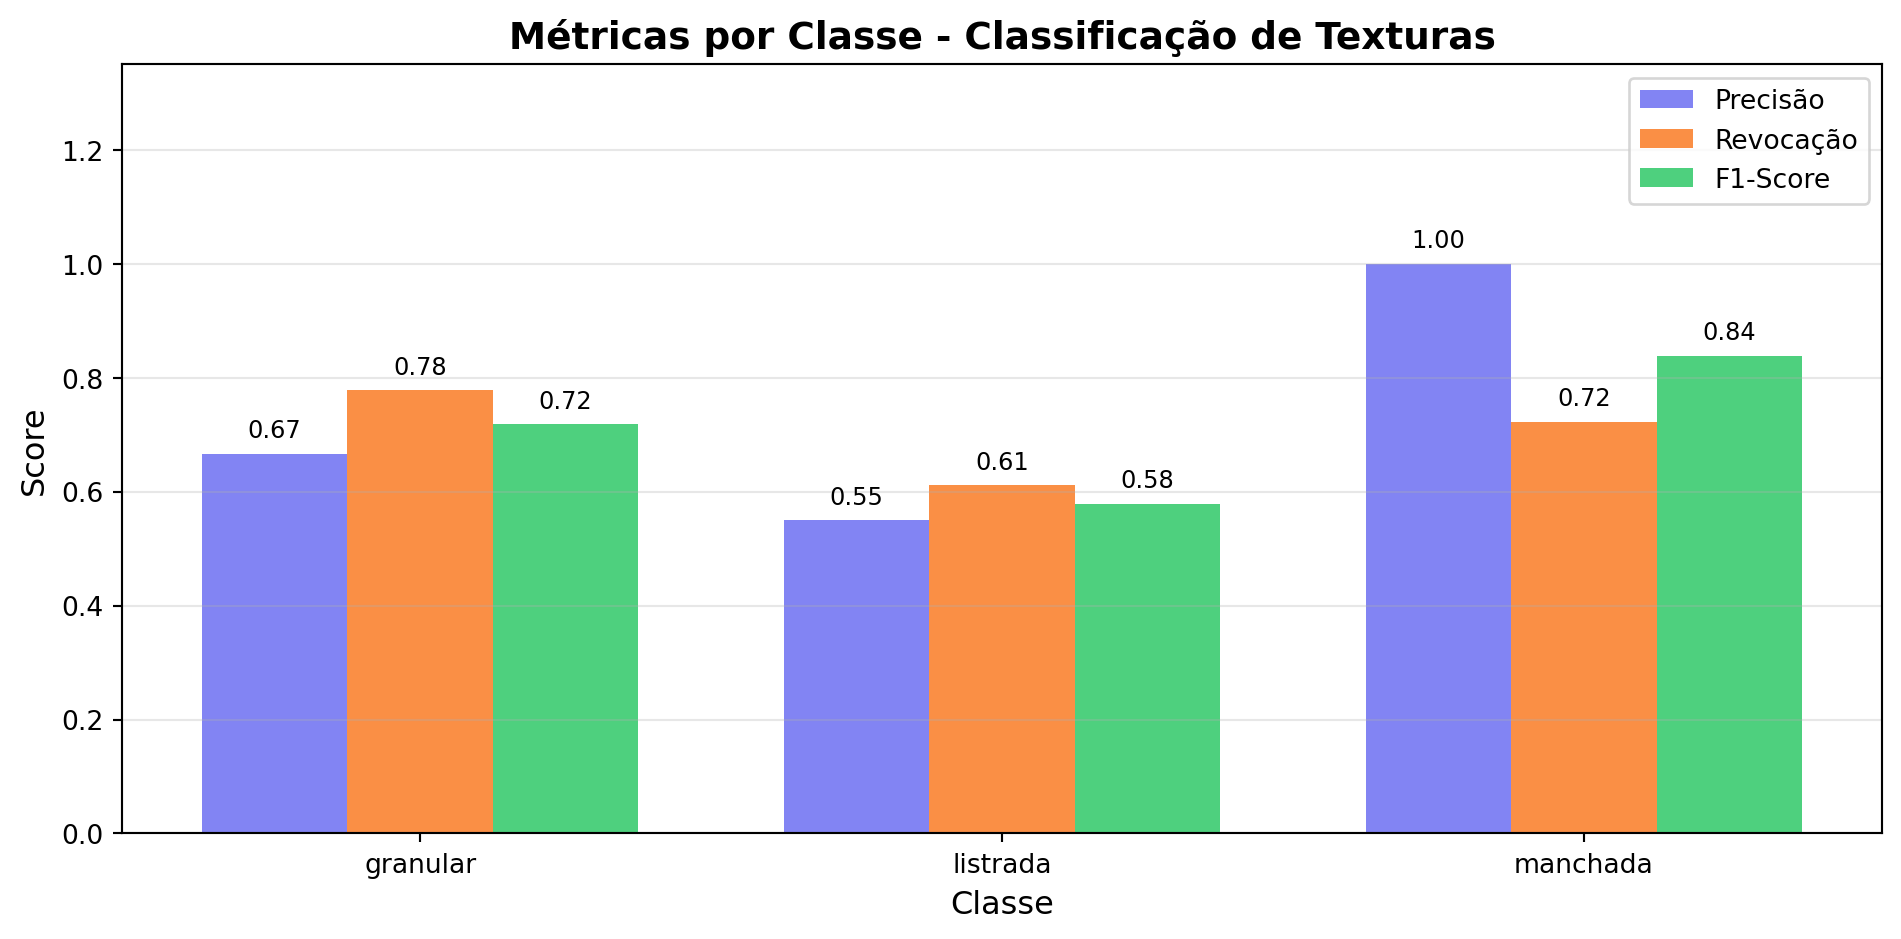

**Figure 7.20:** Detailed evaluation metrics for the k-NN classifier with LBP descriptors


Interpretation of the metrics:
- Precision: among the samples classified as belonging to the class, how many were correct?
- Recall: among the samples that actually belong to the class, how many were identified?
- F1-Score: harmonic mean between precision and recall.
- Support: number of actual samples of each class present in the test set.

Support does not measure performance; it only informs how many examples of each class were 
used in the evaluation.


In [19]:
X_lbp_data = np.array(X_lbp)
y_textura_data = np.array(y_textura)

# Perform a train/test split for the detailed report
Xt_treino, Xt_teste, yt_treino, yt_teste = train_test_split(
    X_lbp_data, y_textura_data, test_size=0.3, random_state=42, stratify=y_textura_data
)

# Scale the data
scaler = StandardScaler()
Xt_treino_scaled = scaler.fit_transform(Xt_treino)
Xt_teste_scaled = scaler.transform(Xt_teste)

# Train the k-NN classifier
knn_textura = KNeighborsClassifier(n_neighbors=5)
knn_textura.fit(Xt_treino_scaled, yt_treino)

y_pred = knn_textura.predict(Xt_teste_scaled)

report = classification_report(
    yt_teste,
    y_pred,
    target_names=classes_textura,
    output_dict=True
)

print("=== DETAILED CLASSIFICATION REPORT ===")
print(f"{'Class':<12} {'Precision':>10} {'Recall':>12} {'F1-score':>10} {'Support':>10}")
for classe in classes_textura:
    r = report[classe]
    print(f"{classe:<12} {r['precision']:>10.2f} {r['recall']:>12.2f} "
          f"{r['f1-score']:>10.2f} {r['support']:>10.0f}")

precision = precision_score(yt_teste, y_pred, average=None, labels=classes_textura)
recall = recall_score(yt_teste, y_pred, average=None, labels=classes_textura)
f1 = f1_score(yt_teste, y_pred, average=None, labels=classes_textura)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes_textura))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precisão', color='#6366f1', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Revocação', color='#f97316', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#22c55e', alpha=0.8)

ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métricas por Classe - Classificação de Texturas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes_textura)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.35)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Interpretation of the metrics:")
print("- Precision: among the samples classified as belonging to the class,",
      "how many were correct?")
print("- Recall: among the samples that actually belong to the class, how many",
      "were identified?")
print("- F1-Score: harmonic mean between precision and recall.")
print("- Support: number of actual samples of each class present in the test set.")
print("\nSupport does not measure performance; it only informs how many examples of each",
      "class were \nused in the evaluation.")

## 7.14 Limitations of Handcrafted Descriptors

The experiments in this chapter show that classical descriptors can be
quite effective in classification tasks, but they also present
important limitations:

- **Specificity:** each descriptor was developed to represent a
  particular type of information, such as color, texture, or shape. Thus, a
  descriptor suitable for one task may not be the most appropriate for
  another.
- **Hyperparameter dependence:** the performance of descriptors such as
  LBP and HOG depends on the choice of parameters, such as neighborhood radius,
  number of sampled points, cell size, and number of orientations,
  which need to be adjusted according to the application.
- **Limited representation:** color, texture, and gradient descriptors
  capture low-level properties of the image, but they do not directly
  represent more complex semantic concepts, such as objects or scenes.
- **Curse of dimensionality:** overly extensive descriptors can
  reduce the effectiveness of distance-based classifiers, such as
  *k*-NN.

These limitations motivate the evolution of the techniques studied in the next
chapters. **Chapter 8** presents classical methods for detection and
matching of features in images, while **Chapter 9**
introduces **Convolutional Neural Networks**, capable of automatically
learning appropriate representations for each task from the
data.

## 7.15 Summary

This chapter presented the fundamentals of pattern recognition applied to images. The main concepts studied were:

- ***Pipeline* of pattern recognition:** acquisition, preprocessing, descriptor extraction, classification, and evaluation.
- **Classical descriptors:** color descriptors, LBP for texture, and HOG for shape, used to represent different characteristics of images.
- **Feature normalization:** standardization (*Z-score*) to prevent attributes of greater magnitude from dominating distance calculations.
- ***k*-NN classifier:** classification based on the $k$ nearest neighbors in feature space.
- **Choice of parameter $k$:** influence of the value of $k$ on classifier performance and the use of cross-validation for its selection.
- **Classifier evaluation:** accuracy, confusion matrix, precision, recall, and F1-score as complementary performance metrics.
- **Limitations of handcrafted descriptors:** specificity, dependence on hyperparameters, and difficulty in representing high-level information.

The concepts were illustrated through experiments with the public dataset `load_digits`, synthetic textures generated for educational purposes, and simulated fruit descriptor data.

## 7.16 🤖 Using Gemini Notebook as a Tutor

In this edition, **Gemini Notebook** is presented as a study support tool.
The system uses exclusively the documents provided by the author as a
source of knowledge, allowing you to explore the chapter's concepts
through questions, summaries, and explanations related to the
studied material.

> ### ❗ 🎓 Study with the Intelligent Tutor
>
> [🚀 ACCESS Gemini Notebook: CHAPTER 07](https://notebooklm.google.com/notebook/494d06c6-ca01-4cd2-aa00-dbe30469308c)
>
> #### 🌐 Language and Programming Language
>
> The project for this chapter in Gemini Notebook was built solely with the text in **Portuguese** and the code examples in **Python**. If you are studying from the English or French edition, or following the C++ track, the tutor's answers may not correspond exactly to the version you are reading.
>
> #### ⚠️ Notice about AI-Generated Content
>
> Answers provided by Gemini Notebook may contain inaccuracies or
> omissions. When necessary, confirm the information using the
> material from this chapter and other reliable academic sources. Running
> the practical examples presented throughout the text remains the
> best way to consolidate the concepts studied.

## 7.17 Exercise List

The following exercises explore and extend the concepts presented in this chapter through adaptations of the implemented algorithms, experimental analyses, and comparisons between different approaches.

1. **(10%)** Implement a color descriptor (RGB or HSV histogram, with at least 16 *bins* per channel) for the three classes of simulated fruits in [Figure 7.1](#fig-07-frutas-motivacao). Train a *k*-NN classifier with this descriptor, compare its accuracy with that obtained by the LBP and HOG descriptors ([Figure 7.9](#fig-07-comparacao-descritores-detalhada)), and discuss in which situations color information is more discriminative.

2. **(15%)** Investigate the effect of feature normalization (*Z-score*) on the performance of *k*-NN in a heterogeneous attribute space, combining color, LBP, and HOG descriptors into a single vector. Compare the results obtained with and without normalization for at least three values of $k$.

3. **(15%)** Reproduce the *overfitting* and *underfitting* analysis from [Figure 7.17](#fig-07-overfitting-analysis) by varying the training set size (e.g., 20%, 50%, and 80% of the `load_digits` dataset). Discuss how the number of examples influences the choice of the $k$ value.

4. **(15%)** Extend Practical Project 2 by adding a fourth synthetic texture class. Evaluate precision, recall, and F1-score for each class, following the pattern in [Figure 7.20](#fig-07-metricas-avaliacao-detalhadas), and analyze the impact of the new class on the confusion matrix.

5. **(15%)** Manually implement the *k*-NN classifier, without using `sklearn`:

   `sklearn.neighbors.KNeighborsClassifier`,

   completing the `knn_passo_a_passo` function presented in the chapter. Compare the accuracy and execution time of the manual implementation with the `scikit-learn` implementation on datasets of increasing sizes and relate the results to the curse of dimensionality.

6. **(15%)** Investigate the influence of the `orientations`, `pixels_per_cell`, and `cells_per_block` parameters of the HOG descriptor on the `load_digits` dataset. Evaluate at least four parameter combinations and discuss the trade-off between descriptor dimensionality and classifier performance.

7. **(15%)** Evaluate the influence of the parameters $P$ (number of neighbors) and $R$ (radius) of the LBP descriptor on the classification of the synthetic textures from Practical Project 2, considering $P \in \{4,8,16\}$ and $R \in \{1,2,3\}$. Analyze how these parameters affect the discriminative capability of the descriptor.

8. **(Bonus – 10%)** Manually implement *k*-fold cross-validation for the *k*-NN classifier on the `load_digits` dataset, without using `cross_val_score`, and compare the results with those obtained by the `scikit-learn` implementation presented in [Figure 7.16](#fig-07-elbow-k).

## Chapter References

The theoretical foundation and experiments presented in this chapter are based on the following references:

- Gonzalez (2018), for the fundamentals of statistical texture descriptors and the preprocessing operations applied to feature extraction.
- Szeliski (2022), for the presentation of the classical pattern recognition pipeline, descriptor extraction, and classifier evaluation in Computer Vision.
- Duda (2001), for the theoretical foundations of pattern recognition, the *k*-NN classifier, and the bias-variance trade-off.
- Cover (1967), for the original formulation of the *k* nearest neighbors algorithm.
- Ojala (2002), for the formulation of the *Local Binary Patterns* (LBP) descriptor and its uniform variant, used in this chapter.
- Dalal (2005), for the formulation of the *Histogram of Oriented Gradients* (HOG) descriptor, employed in shape and contour representation.
- Pedregosa (2011), for the implementation of the *k*-NN classifier, evaluation metrics, and cross-validation in the `scikit-learn` library.
- Quilici-gonzalez (2014), for the didactic presentation of traditional Pattern Recognition classifiers, such as Decision Trees, Classification Rules, and Support Vector Machines (SVM), complementary to the k-NN classifier explored in this chapter.
- Quilici-gonzalez (2026), for the update and expansion of these contents in its 2nd edition, currently in production.

## Chapter References


COVER, T.; HART, P. **Nearest neighbor pattern classification**. 1967.

DALAL, N.; TRIGGS, B. **Histograms of oriented gradients for human detection**. 2005.

DUDA, Richard O.; HART, Peter E.; STORK, David G. **Pattern Classification**. New York, Wiley-Interscience, 2001.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

OJALA, Timo; PIETIK\"{A}INEN, Matti; M\"{A}ENP\"{A}\"{A}, Topi. **Multiresolution Gray-Scale and Rotation Invariant Texture Classification with Local Binary Patterns**. USA, IEEE Computer Society, 2002.

PEDREGOSA, Fabian *et al*. **Scikit-learn: Machine Learning in Python**. 2011.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis. **Sistemas Inteligentes e Mineração de Dados**. Editora UFABC, 2014.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis; SOUZA, Fábio Rezende de. **Sistemas Inteligentes e Mineração de Dados: Do Weka ao Python**. 2026.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

{GOOGLE}. **{NotebookLM}**. 2025.